In [1]:
# in a notebook cell
!pip install ipympl ipywidgets


# Time converting

In [279]:
from pathlib import Path
import pandas as pd

# ===== folders =====
input_folder = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle")
output_folder = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime")
output_folder.mkdir(parents=True, exist_ok=True)
from pathlib import Path
import pandas as pd

# ===== find csv files =====
csv_files = sorted(input_folder.glob("*.csv"))
# if you also want subfolders, use:
# csv_files = sorted(input_folder.rglob("*.csv"))

for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    if "host_time_s" not in df.columns:
        print(f"Skipped (no host_time_s): {csv_file.name}")
        continue

    # add timestamp_la while keeping all original columns unchanged
    df["timestamp"] = (
        pd.to_datetime(pd.to_numeric(df["host_time_s"], errors="coerce"), unit="s", utc=True)
        .dt.tz_convert("America/Los_Angeles")
        .dt.strftime("%Y-%m-%d %H:%M:%S.%f")
    )

    # save as originalname_LAtime.csv
    out_file = output_folder / f"{csv_file.stem}.csv"
    # out_file = output_folder / f"{csv_file.stem}_LAtime.csv"
    df.to_csv(out_file, index=False)

    print(f"Saved: {out_file}")

print(f"Done. Processed {len(csv_files)} files.")

Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-10_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-1_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-2_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-3_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-4_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-5_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-6_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-7_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/3_angle/emg_LAtime/3-8_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/2601

# Preprocessing

In [12]:
from pathlib import Path
import pandas as pd

def extract_relay_switch_events_df(
    df,
    time_col="timestamp_la",
    relay_col="relay_on",
    modality_col="modality",
    relay_modality_value="RELAY",
    keep_all_relay_rows=False,
):
    # ---- pick rows that have relay info ----
    mask = pd.Series(False, index=df.index)

    if modality_col in df.columns:
        mask |= df[modality_col].astype(str).str.upper().str.strip().eq(relay_modality_value)

    if relay_col in df.columns:
        mask |= df[relay_col].notna()

    relay_df = df[mask].copy()
    if len(relay_df) == 0:
        return pd.DataFrame(columns=["timestamp", "relay_state"])

    # ---- parse time ----
    if time_col not in relay_df.columns:
        return pd.DataFrame(columns=["timestamp", "relay_state"])

    relay_df["timestamp_dt"] = pd.to_datetime(relay_df[time_col], errors="coerce")
    relay_df = relay_df.dropna(subset=["timestamp_dt"]).sort_values("timestamp_dt").copy()

    # ---- numeric relay state ----
    if relay_col not in relay_df.columns:
        return pd.DataFrame(columns=["timestamp", "relay_state"])

    relay_df[relay_col] = pd.to_numeric(relay_df[relay_col], errors="coerce")
    relay_df = relay_df.dropna(subset=[relay_col]).copy()
    if len(relay_df) == 0:
        return pd.DataFrame(columns=["timestamp", "relay_state"])

    relay_df["relay_state"] = relay_df[relay_col].round().astype(int)

    # ---- keep only state changes (switching instants) ----
    if not keep_all_relay_rows:
        changed = relay_df["relay_state"].ne(relay_df["relay_state"].shift(1))
        relay_df = relay_df[changed].copy()

    out = relay_df[["timestamp_dt", "relay_state"]].rename(columns={"timestamp_dt": "timestamp"})
    return out.reset_index(drop=True)


def batch_extract_relay_events(
    in_dir,
    out_dir,
    pattern="*.csv",
    suffix=".csv",
    keep_all_relay_rows=False,
):
    in_dir = Path(in_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted([p for p in in_dir.glob(pattern) if p.is_file()])
    print(f"Found {len(files)} file(s) in {in_dir} matching {pattern}")

    for fp in files:
        try:
            df = pd.read_csv(fp)
            relay_out = extract_relay_switch_events_df(df, keep_all_relay_rows=keep_all_relay_rows)

            out_path = out_dir / f"{fp.stem}{suffix}"
            relay_out.to_csv(out_path, index=False)
            print("Saved:", out_path, "| rows:", len(relay_out))

        except Exception as e:
            print("[ERROR]", fp.name, "->", repr(e))

    print("Done.")

In [13]:
batch_extract_relay_events(
    in_dir="/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime",
    out_dir="/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching",
    pattern="*.csv",
    keep_all_relay_rows=False,   # True if you want every relay row
)


Found 45 file(s) in /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime matching *.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-0_LAtime.csv | rows: 476
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-10_LAtime.csv | rows: 1289
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-1_LAtime.csv | rows: 2972
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-2_LAtime.csv | rows: 2282
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-3_LAtime.csv | rows: 1572
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-4_LAtime.csv | rows: 1728
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching/1-5_LAtime.csv | rows: 1601
Saved: /Users/mmz/Rehab_sensing/260113_da

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np

def _get_time_series(df):
    """
    Prefer timestamp_la; fallback to timestamp; fallback to host_time_s.
    Returns a sorted datetime Series named 't'.
    """
    if "timestamp_la" in df.columns:
        t = pd.to_datetime(df["timestamp_la"], errors="coerce")
    elif "timestamp" in df.columns:
        t = pd.to_datetime(df["timestamp"], errors="coerce")
    elif "host_time_s" in df.columns:
        # unix seconds -> datetime
        t = pd.to_datetime(pd.to_numeric(df["host_time_s"], errors="coerce"), unit="s", errors="coerce")
    else:
        raise KeyError(f"No usable time column found. Columns: {list(df.columns)}")

    # Drop NaT, sort
    out = df.copy()
    out["t"] = t
    out = out.dropna(subset=["t"]).sort_values("t").reset_index(drop=True)
    return out

def infer_relay_events_from_emg_gaps(
    df_in,
    gap_threshold_ms=60,     # detect "about 80ms" gaps; 60ms is a safe threshold
    min_samples_between=5,   # ignore tiny bursts that can create false gaps
):
    """
    Returns a relay event dataframe with columns:
      timestamp_la (or timestamp), timestamp_dt, relay_state, gap_ms

    For each detected gap (dt >= gap_threshold_ms):
      event at t_before => relay_state=1
      event at t_after  => relay_state=0
    """
    df = _get_time_series(df_in)

    # (optional) keep only EMG rows if src column exists
    if "src" in df.columns:
        df = df[df["src"].astype(str).str.upper() == "EMG"].copy()
        df = df.reset_index(drop=True)

    if len(df) < 2:
        return pd.DataFrame(columns=["timestamp_dt", "relay_state", "gap_ms", "event"])

    # compute dt in ms
    dt_ms = df["t"].diff().dt.total_seconds() * 1000.0
    df["dt_ms"] = dt_ms

    # indices where a large gap occurs between i-1 and i
    gap_idx = np.where(df["dt_ms"].to_numpy() >= gap_threshold_ms)[0]

    # optional: suppress multiple gaps that are too close (noise)
    # keep a gap only if there are at least min_samples_between samples since last gap
    keep = []
    last = -10**9
    for i in gap_idx:
        if (i - last) >= min_samples_between:
            keep.append(i)
            last = i
    gap_idx = np.array(keep, dtype=int)

    events = []
    for i in gap_idx:
        t_before = df.loc[i-1, "t"]
        t_after  = df.loc[i, "t"]
        gap_val  = float(df.loc[i, "dt_ms"])

        # per your rule:
        events.append({"timestamp_dt": t_before, "relay_state": 1, "gap_ms": gap_val, "event": "before_gap"})
        events.append({"timestamp_dt": t_after,  "relay_state": 0, "gap_ms": gap_val, "event": "after_gap"})

    relay_df = pd.DataFrame(events).sort_values("timestamp_dt").reset_index(drop=True)

    # also write a string timestamp column for saving (match your other files)
    relay_df["timestamp_la"] = relay_df["timestamp_dt"].dt.strftime("%Y-%m-%d %H:%M:%S.%f")

    # keep minimal columns (plus gap_ms is useful for debugging)
    return relay_df[["timestamp_la", "relay_state", "gap_ms", "event"]]


In [16]:
def infer_relay_for_dir(
    in_dir,
    out_dir,
    pattern="4-*.csv",
    gap_threshold_ms=60,
):
    in_dir = Path(in_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted(in_dir.glob(pattern))
    print(f"Found {len(files)} file(s) matching {pattern} in {in_dir}")

    for p in files:
        try:
            df = pd.read_csv(p)
            relay_df = infer_relay_events_from_emg_gaps(df, gap_threshold_ms=gap_threshold_ms)

            out_path = out_dir / f"{p.stem}.csv"
            relay_df.to_csv(out_path, index=False)

            print(f"[ok] {p.name} -> {out_path.name} | events={len(relay_df)}")

        except Exception as e:
            print(f"[ERR] {p.name}: {repr(e)}")

    print("Done.")

# Example:
infer_relay_for_dir(
    in_dir="/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime",
    out_dir="/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/0_relay_switching",
    pattern="4-*_LAtime.csv",     # or "4-*.csv" depending on your exact filenames
    gap_threshold_ms=60,          # start here; if you miss gaps, lower to 50; if too many false, raise to 70
)


Found 1 file(s) matching 5-*_LAtime.csv in /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime
[ok] 5-0_LAtime.csv -> 5-0_LAtime.csv | events=840
Done.


In [17]:
from pathlib import Path
import pandas as pd

def split_emg_and_angle_to_dirs(
    in_csv,
    emg_out_dir,
    angle_out_dir,
    src_col="src",
):
    in_csv = Path(in_csv)
    emg_out_dir = Path(emg_out_dir)
    angle_out_dir = Path(angle_out_dir)

    emg_out_dir.mkdir(parents=True, exist_ok=True)
    angle_out_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(in_csv)

    # normalize src if present
    if src_col in df.columns:
        src = df[src_col].astype(str).str.upper().str.strip()
    else:
        src = pd.Series([""] * len(df), index=df.index)

    # -----------------------
    # EMG: src == "EMG"
    # -----------------------
    emg_df = df[src == "EMG"].copy() if src_col in df.columns else df.copy()

    emg_keep = [
        "host_time_s","host_rel_s","device_us","device_s",
        "trial_id","label","mark",
        "emg0","emg1","emg2","emg3",
        "relay_on",
        src_col
    ]
    emg_keep = [c for c in emg_keep if c in emg_df.columns]
    emg_df = emg_df[emg_keep]

    emg_out = emg_out_dir / f"{in_csv.stem}.csv"
    emg_df.to_csv(emg_out, index=False)

    # -----------------------
    # ANGLE: rows with valid angle_deg
    # -----------------------
    angle_out = None
    angle_rows = 0

    if "angle_deg" in df.columns:
        angle_df = df.copy()
        angle_df["angle_deg"] = pd.to_numeric(angle_df["angle_deg"], errors="coerce")
        angle_df = angle_df.dropna(subset=["angle_deg"]).copy()
        angle_rows = len(angle_df)

        if angle_rows > 0:
            angle_keep = [
                "host_time_s","host_rel_s","device_us","device_s",
                "trial_id","label","mark",
                "angle_deg",
                src_col
            ]
            angle_keep = [c for c in angle_keep if c in angle_df.columns]
            angle_df = angle_df[angle_keep]

            angle_out = angle_out_dir / f"{in_csv.stem}.csv"
            angle_df.to_csv(angle_out, index=False)

    print("Input:", in_csv.name)
    print("  Saved EMG  :", emg_out, "rows:", len(emg_df))
    if angle_out is not None:
        print("  Saved ANGLE:", angle_out, "rows:", angle_rows)
    else:
        print("  No ANGLE rows found (angle_deg missing or all NaN).")

    return emg_out, angle_out


In [275]:
from pathlib import Path

in_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime")
emg_out_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg")
angle_out_dir = Path("//Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/2_angle")

for p in sorted(in_dir.glob("*.csv")):
    split_emg_and_angle_to_dirs(p, emg_out_dir, angle_out_dir)


Input: 1-0_LAtime.csv
  Saved EMG  : /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/1-0_LAtime.csv rows: 17376
  No ANGLE rows found (angle_deg missing or all NaN).
Input: 1-10_LAtime.csv
  Saved EMG  : /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/1-10_LAtime.csv rows: 47048
  No ANGLE rows found (angle_deg missing or all NaN).
Input: 1-1_LAtime.csv
  Saved EMG  : /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/1-1_LAtime.csv rows: 108512
  No ANGLE rows found (angle_deg missing or all NaN).
Input: 1-2_LAtime.csv
  Saved EMG  : /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/1-2_LAtime.csv rows: 83247
  No ANGLE rows found (angle_deg missing or all NaN).
Input: 1-3_LAtime.csv
  Saved EMG  : /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/1-3_LAtime.csv rows: 57404
  No ANGLE rows found (angle_deg missing or all NaN).
Input: 1-4_LAtime.csv
  Saved EMG  : 

In [19]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

# =========================
# CONFIG
# =========================
in_dir  = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime")
out_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/4_height")
out_dir.mkdir(parents=True, exist_ok=True)

FILE_GLOB = "4-*_LAtime.csv"

LABEL_COL = "label_id"     # <-- key fix
LABEL_CM_COL = "label_cm"  # optional
TIME_COL = "timestamp_la"
SRC_COL = "src"
SRC_VALUE = "EMG"

EMG_COLS = ["emg0", "emg1", "emg2", "emg3"]

# Expect label_id = 0..7
EXPECTED_LABELS = list(range(8))

# Match "4-12_LAtime.csv" -> trial=12
trial_re = re.compile(r"^4-(\d+)_LAtime\.csv$", re.IGNORECASE)

# label -> list of dfs
by_label = {lbl: [] for lbl in EXPECTED_LABELS}

csv_files = sorted([p for p in in_dir.glob(FILE_GLOB) if p.is_file()])
print(f"Found {len(csv_files)} files in {in_dir} matching {FILE_GLOB}")

for fp in csv_files:
    m = trial_re.match(fp.name)
    if not m:
        print("[skip] unexpected filename:", fp.name)
        continue

    trial_num = int(m.group(1))
    trial_name = f"4-{trial_num}"

    df = pd.read_csv(fp)

    # ---- keep EMG rows only ----
    if SRC_COL in df.columns:
        emg = df[df[SRC_COL].astype(str).str.upper().str.strip() == SRC_VALUE].copy()
    else:
        emg = df.copy()  # fallback if already EMG-only

    if len(emg) == 0:
        print("[warn] no EMG rows:", fp.name)
        continue

    # ---- check required label column ----
    if LABEL_COL not in emg.columns:
        print(f"[warn] no {LABEL_COL} column:", fp.name)
        continue

    # ---- parse time ----
    if TIME_COL in emg.columns:
        emg["time_dt"] = pd.to_datetime(emg[TIME_COL], errors="coerce")
        emg = emg.dropna(subset=["time_dt"]).sort_values("time_dt").copy()
        emg["time"] = emg["time_dt"]
    else:
        # fallback if timestamp_la missing
        if "host_rel_s" not in emg.columns:
            print("[warn] no timestamp_la or host_rel_s:", fp.name)
            continue
        emg["host_rel_s"] = pd.to_numeric(emg["host_rel_s"], errors="coerce")
        emg = emg.dropna(subset=["host_rel_s"]).sort_values("host_rel_s").copy()
        emg["time"] = emg["host_rel_s"]

    # ---- numeric EMG ----
    for c in EMG_COLS:
        if c in emg.columns:
            emg[c] = pd.to_numeric(emg[c], errors="coerce")
    emg = emg.dropna(subset=EMG_COLS, how="any").copy()

    # ---- normalize label_id ----
    emg[LABEL_COL] = pd.to_numeric(emg[LABEL_COL], errors="coerce")
    emg = emg.dropna(subset=[LABEL_COL]).copy()
    emg[LABEL_COL] = emg[LABEL_COL].astype(int)

    # keep only 0..7
    emg = emg[emg[LABEL_COL].isin(EXPECTED_LABELS)].copy()

    if len(emg) == 0:
        print("[warn] no rows with label_id 0..7:", fp.name)
        continue

    # ---- contiguous segments within this trial (label blocks) ----
    label_change = (emg[LABEL_COL] != emg[LABEL_COL].shift(1)).fillna(True)
    emg["segment_id"] = label_change.cumsum().astype(int)

    emg["segment_start"] = emg.groupby("segment_id")["time"].transform("min")
    emg["segment_end"]   = emg.groupby("segment_id")["time"].transform("max")

    # ---- annotate trial ----
    emg["trial_from_filename"] = trial_num
    emg["trial_name"] = trial_name

    # ---- keep cols ----
    keep_cols = [
        "trial_from_filename", "trial_name",
        LABEL_COL, "segment_id", "segment_start", "segment_end",
        "time"
    ] + EMG_COLS

    # include label_cm if present
    if LABEL_CM_COL in emg.columns:
        keep_cols.insert(keep_cols.index(LABEL_COL) + 1, LABEL_CM_COL)

    emg_keep = emg[keep_cols].copy()

    # ---- bucket into labels ----
    for lbl, sub in emg_keep.groupby(LABEL_COL):
        by_label[int(lbl)].append(sub)

    print(f"Processed {fp.name}: rows={len(emg_keep)}, unique label_id={emg_keep[LABEL_COL].nunique()}")

# =========================
# Save 8 files: label_id_0..7
# =========================
for lbl in EXPECTED_LABELS:
    parts = by_label[lbl]
    out_csv = out_dir / f"label_id_{lbl}.csv"

    if len(parts) == 0:
        # write empty file with columns
        cols = [
            "trial_from_filename","trial_name",
            LABEL_COL, LABEL_CM_COL,
            "segment_id","segment_start","segment_end","time",
            *EMG_COLS
        ]
        cols = [c for c in cols if c != LABEL_CM_COL or LABEL_CM_COL in (parts[0].columns if parts else [])]
        pd.DataFrame(columns=cols).to_csv(out_csv, index=False)
        print("[warn] wrote empty:", out_csv)
        continue

    df_lbl = pd.concat(parts, ignore_index=True)
    df_lbl = df_lbl.sort_values(["trial_from_filename", "time"]).reset_index(drop=True)
    df_lbl["x"] = np.arange(len(df_lbl))  # continuous index within this label file

    df_lbl.to_csv(out_csv, index=False)
    print("Saved:", out_csv, "rows:", len(df_lbl))

print("\nDone. Output folder:", out_dir)


Found 11 files in /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime matching 4-*_LAtime.csv
Processed 4-0_LAtime.csv: rows=73807, unique label_id=8
Processed 4-10_LAtime.csv: rows=64350, unique label_id=8
Processed 4-1_LAtime.csv: rows=101924, unique label_id=8
Processed 4-2_LAtime.csv: rows=63086, unique label_id=8
Processed 4-3_LAtime.csv: rows=77437, unique label_id=8
Processed 4-4_LAtime.csv: rows=65571, unique label_id=8
Processed 4-5_LAtime.csv: rows=70650, unique label_id=8
Processed 4-6_LAtime.csv: rows=66991, unique label_id=8
Processed 4-7_LAtime.csv: rows=56968, unique label_id=8
Processed 4-8_LAtime.csv: rows=51670, unique label_id=8
Processed 4-9_LAtime.csv: rows=66816, unique label_id=8
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/4_height/label_id_0.csv rows: 161385
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/4_height/label_id_1.csv rows: 79264
Saved: /Users/mmz/Rehab_sensin

# Functions

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def visualization(csv_path, t_start=None, t_end=None):
    df = pd.read_csv(csv_path)

    # Parse LA timestamp column
    df["timestamp_dt"] = pd.to_datetime(df["timestamp_la"], errors="coerce")
    df = df.dropna(subset=["timestamp_dt"]).sort_values("timestamp_dt")

    # If no time slot specified, use full range
    if t_start is None:
        t_start = df["timestamp_dt"].min()
    else:
        t_start = pd.to_datetime(t_start)

    if t_end is None:
        t_end = df["timestamp_dt"].max()
    else:
        t_end = pd.to_datetime(t_end)

    slot = df[(df["timestamp_dt"] >= t_start) & (df["timestamp_dt"] <= t_end)].copy()
    print("Rows in slot:", len(slot))

    # Filter EMG
    emg_df = slot[slot["modality"] == "EMG"].copy()
    for c in ["emg0", "emg1", "emg2", "emg3"]:
        emg_df[c] = pd.to_numeric(emg_df[c], errors="coerce")
    emg_df = emg_df.dropna(subset=["emg0", "emg1", "emg2", "emg3"]).sort_values("timestamp_dt")

    # Filter RELAY (optional markers)
    relay_df = slot[slot["modality"] == "RELAY"].copy()
    relay_df["relay_on"] = pd.to_numeric(relay_df["relay_on"], errors="coerce")
    relay_df = relay_df.dropna(subset=["relay_on"]).sort_values("timestamp_dt")

    # Plot
    t = emg_df["timestamp_dt"]
    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
    channels = ["emg0", "emg1", "emg2", "emg3"]

    for i, ch in enumerate(channels):
        axes[i].plot(t, emg_df[ch], linewidth=1)
        axes[i].set_ylabel(ch)
        axes[i].grid(True)

    axes[-1].set_xlabel("LA Time")
    fig.suptitle(f"EMG (LA time)\n{t_start} → {t_end}", y=0.98)
    plt.tight_layout()
    plt.show()


In [315]:
import pandas as pd
import matplotlib.pyplot as plt

def visualization_by_index(csv_path, t_start=None, t_end=None, show_relay_markers=False):
    df = pd.read_csv(csv_path)

    # ---------- Parse timestamp ----------
    if "timestamp_la" in df.columns:
        df["timestamp_dt"] = pd.to_datetime(df["timestamp_la"], errors="coerce")
        df = df.dropna(subset=["timestamp_dt"]).sort_values("timestamp_dt")
    elif "host_time_s" in df.columns:
        # fallback: epoch seconds
        df["timestamp_dt"] = pd.to_datetime(df["host_time_s"], unit="s", errors="coerce")
        df = df.dropna(subset=["timestamp_dt"]).sort_values("timestamp_dt")
    else:
        df["timestamp_dt"] = pd.NaT  # allow running without time

    # ---------- Optional time slot ----------
    if t_start is not None and t_end is not None and df["timestamp_dt"].notna().any():
        t_start = pd.to_datetime(t_start)
        t_end   = pd.to_datetime(t_end)
        slot = df[(df["timestamp_dt"] >= t_start) & (df["timestamp_dt"] <= t_end)].copy()
    else:
        slot = df.copy()

    # ---------- Determine how to filter EMG/RELAY ----------
    # Prefer 'modality', else 'src', else assume EMG-only file
    if "modality" in slot.columns:
        type_col = "modality"
    elif "src" in slot.columns:
        type_col = "src"
    else:
        type_col = None

    # ---------- Filter EMG ----------
    if type_col is None:
        emg_df = slot.copy()  # assume already EMG-only
    else:
        emg_df = slot[slot[type_col] == "EMG"].copy()

    for c in ["emg0", "emg1", "emg2", "emg3"]:
        if c in emg_df.columns:
            emg_df[c] = pd.to_numeric(emg_df[c], errors="coerce")

    emg_df = emg_df.dropna(subset=["emg0", "emg1", "emg2", "emg3"]).reset_index(drop=True)

    print("EMG rows:", len(emg_df))
    if len(emg_df) == 0:
        print("No EMG rows found. Check the file columns:", list(df.columns))
        return

    # Continuous index: 0,1,2,... (no gaps)
    x = emg_df.index.to_numpy()

    # ---------- Relay events (optional) ----------
    relay_x = []
    relay_state = []

    if show_relay_markers:
        if type_col is None:
            print("Note: This looks like an EMG-only file (no modality/src). No relay markers available.")
        else:
            relay_df = slot[slot[type_col] == "RELAY"].copy()
            if len(relay_df) == 0:
                print("Note: No RELAY rows in this file. Use the raw file if you want relay markers.")
            elif "relay_on" in relay_df.columns and slot["timestamp_dt"].notna().any():
                relay_df["relay_on"] = pd.to_numeric(relay_df["relay_on"], errors="coerce")
                relay_df = relay_df.dropna(subset=["relay_on"]).sort_values("timestamp_dt")

                # Map relay timestamps to nearest EMG index
                if "timestamp_dt" in emg_df.columns and emg_df["timestamp_dt"].notna().any():
                    for _, r in relay_df.iterrows():
                        ts = r["timestamp_dt"]
                        j = emg_df["timestamp_dt"].searchsorted(ts)
                        if j < len(emg_df):
                            relay_x.append(int(j))
                            relay_state.append(int(r["relay_on"]))

    # ---------- Plot ----------
    fig, axes = plt.subplots(4, 1, figsize=(8,6), sharex=True)
    channels = ["emg0", "emg1", "emg2", "emg3"]

    for i, ch in enumerate(channels):
        axes[i].plot(x, emg_df[ch].to_numpy(), linewidth=1)
        axes[i].set_ylabel(ch)
        # axes[i].grid(True)

        if show_relay_markers and relay_x:
            for rx in relay_x:
                axes[i].axvline(rx, linestyle="--", linewidth=0.8)
    
    # axes[0].set_ylim(1000,2500)
    # axes[1].set_ylim(1000,2500)
    # axes[2].set_ylim(1000,2500)
    # axes[3].set_ylim(1000,2500)
    axes[-1].set_xlabel("EMG sample index (continuous)")
    # title = "EMG plotted by continuous index (no time gaps)"
    # if t_start is not None and t_end is not None:
    #     title += f"\n{t_start} → {t_end}"
    # fig.suptitle(title, y=0.98)

    plt.tight_layout()
    plt.show()


In [4]:
import numpy as np
import pandas as pd

def remove_relay_artifacts_by_burst_edges(
    df,
    emg_cols=("emg0","emg1","emg2","emg3"),
    gap_us=8000,       # threshold to detect a new EMG burst (try 8000–20000)
    drop_head=3,       # drop first N samples in each burst (try 3–8)
    drop_tail=0,       # drop last N samples (try 0–3 if you see spikes at the end too)
    interp=True,
):
    # --- EMG only ---
    emg = df[df["modality"] == "EMG"].copy()

    # numeric
    emg["device_us"] = pd.to_numeric(emg["device_us"], errors="coerce")
    for c in emg_cols:
        emg[c] = pd.to_numeric(emg[c], errors="coerce")

    emg = emg.dropna(subset=["device_us", *emg_cols]).sort_values("device_us").reset_index(drop=True)

    # detect burst starts by large time gap
    du = emg["device_us"].diff().fillna(0)
    new_burst = du > gap_us
    burst_id = new_burst.cumsum()

    # position inside each burst + burst length
    pos = emg.groupby(burst_id).cumcount()
    burst_len = emg.groupby(burst_id)["device_us"].transform("size")

    # mark samples to remove
    bad = (pos < drop_head) | (pos >= (burst_len - drop_tail))

    emg_clean = emg.copy()
    emg_clean.loc[bad, list(emg_cols)] = np.nan

    if interp:
        for c in emg_cols:
            emg_clean[c] = emg_clean[c].interpolate(limit_direction="both")

    return emg, emg_clean, bad


In [5]:
import numpy as np
import pandas as pd

EMG_COLS = ["emg0", "emg1", "emg2", "emg3"]

def _to_float(arr):
    a = np.asarray(arr, dtype=float)
    return a[np.isfinite(a)]

def rms_ac(x):
    """RMS after mean removal (AC RMS)."""
    x = _to_float(x)
    if len(x) == 0:
        return np.nan
    x = x - np.mean(x)
    return float(np.sqrt(np.mean(x * x)))

def snr_db_from_segments(signal_seg, noise_seg):
    """20log10(RMS(signal_ac)/RMS(noise_ac))"""
    s_rms = rms_ac(signal_seg)
    n_rms = rms_ac(noise_seg)
    if not np.isfinite(n_rms) or n_rms == 0:
        return np.inf
    return float(20 * np.log10(s_rms / n_rms))

def get_slot(emg_df, i0, i1, col):
    i0 = int(max(0, i0))
    i1 = int(min(len(emg_df) - 1, i1))
    if i1 < i0:
        raise ValueError("i1 must be >= i0")
    return pd.to_numeric(emg_df.iloc[i0:i1+1][col], errors="coerce").to_numpy()

def snr_from_emg_clean(
    emg_clean,
    noise_range,   # (i0, i1) e.g. rest
    signal_range,  # (i0, i1) e.g. bend
    cols=EMG_COLS,
):
    (n0, n1) = noise_range
    (s0, s1) = signal_range

    rows = []
    for ch in cols:
        noise_seg  = get_slot(emg_clean, n0, n1, ch)
        signal_seg = get_slot(emg_clean, s0, s1, ch)

        n_rms = rms_ac(noise_seg)
        s_rms = rms_ac(signal_seg)
        snr   = snr_db_from_segments(signal_seg, noise_seg)

        rows.append({
            "channel": ch,
            "noise_i0": n0, "noise_i1": n1,
            "signal_i0": s0, "signal_i1": s1,
            "noise_rms_ac": n_rms,
            "signal_rms_ac": s_rms,
            "snr_db": snr
        })

    out = pd.DataFrame(rows)

    # Optional: one combined SNR by concatenating all channels
    noise_all  = np.concatenate([get_slot(emg_clean, n0, n1, ch) for ch in cols])
    signal_all = np.concatenate([get_slot(emg_clean, s0, s1, ch) for ch in cols])
    out_all = {
        "channel": "ALL_concat",
        "noise_rms_ac": rms_ac(noise_all),
        "signal_rms_ac": rms_ac(signal_all),
        "snr_db": snr_db_from_segments(signal_all, noise_all),
    }

    return out, out_all


In [7]:
def plot_emg_index(emg_df, title=""):
    x = np.arange(len(emg_df))
    fig, axes = plt.subplots(4,1,sharex=True, figsize=(12,7))
    for i,ch in enumerate(["emg0","emg1","emg2","emg3"]):
        axes[i].plot(x, emg_df[ch].to_numpy(), linewidth=1)
        axes[i].set_ylabel(ch); axes[i].grid(True)
    axes[-1].set_xlabel("EMG sample index")
    fig.suptitle(title, y=0.98)
    plt.tight_layout(); plt.show()

# Execution

### Visualization

In [29]:
# from pathlib import Path
# import pandas as pd

# # ===== folders =====
# input_folder = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg")
# output_folder = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime")
# output_folder.mkdir(parents=True, exist_ok=True)
# from pathlib import Path
# import pandas as pd

# # ===== find csv files =====
# csv_files = sorted(input_folder.glob("*.csv"))
# # if you also want subfolders, use:
# # csv_files = sorted(input_folder.rglob("*.csv"))

# for csv_file in csv_files:
#     df = pd.read_csv(csv_file)

#     if "host_time_s" not in df.columns:
#         print(f"Skipped (no host_time_s): {csv_file.name}")
#         continue

#     # add timestamp_la while keeping all original columns unchanged
#     df["timestamp_la"] = (
#         pd.to_datetime(pd.to_numeric(df["host_time_s"], errors="coerce"), unit="s", utc=True)
#         .dt.tz_convert("America/Los_Angeles")
#         .dt.strftime("%Y-%m-%d %H:%M:%S.%f")
#     )

#     # save as originalname_LAtime.csv
#     out_file = output_folder / f"{csv_file.stem}.csv"
#     df.to_csv(out_file, index=False)

#     print(f"Saved: {out_file}")

# print(f"Done. Processed {len(csv_files)} files.")

Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-0_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-10_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-1_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-2_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-3_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-4_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-5_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-6_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/emg_LAtime/1-7_LAtime.csv
Saved: /Users/mmz/Rehab_sensing/2601

EMG rows: 16900


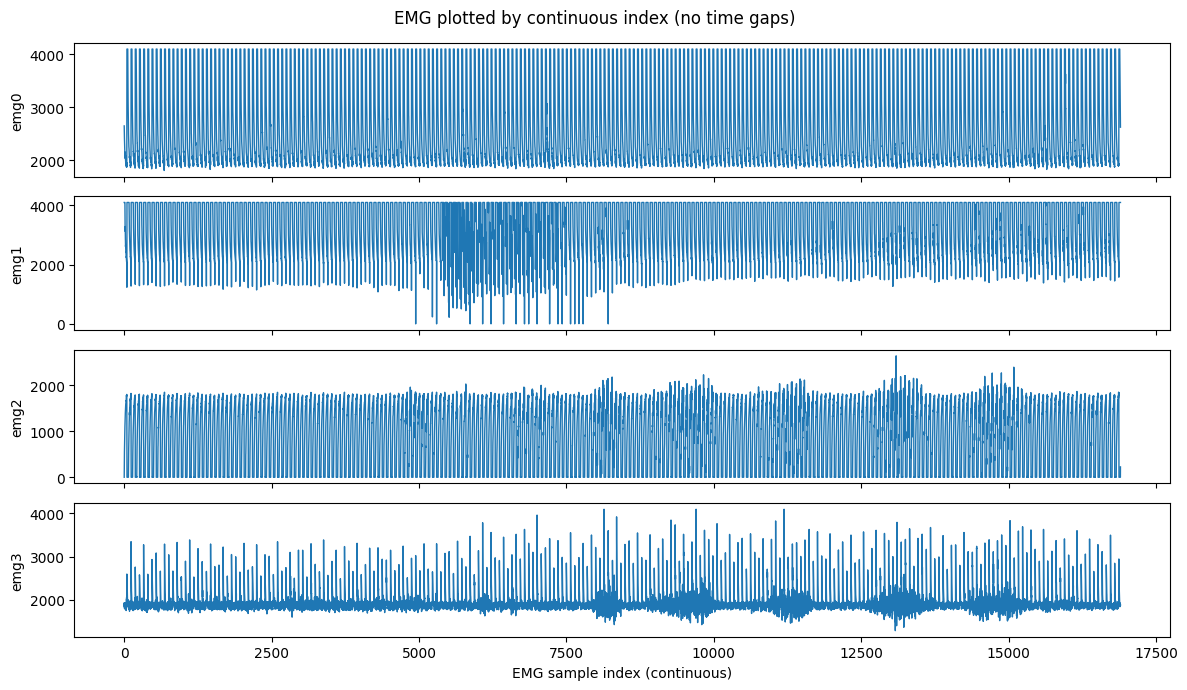

In [287]:
# visualization(csv_path = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260129_data_quality_frequency/30ms_LAtime.csv")
visualization_by_index(csv_path = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg/1-0_LAtime.csv")

# Clean relay peaks

### task1

In [62]:
from pathlib import Path
import pandas as pd

# ---- your functions must already be defined/imported ----
# from your_module import remove_relay_artifacts_by_burst_edges, plot_emg_index

# =========================
# CONFIG: set your folders
# =========================
in_dir  = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime")
out_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg")

out_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Find files starting with "1"
# =========================
csv_files = sorted([p for p in in_dir.glob("1-*.csv") if p.is_file()])

print(f"Found {len(csv_files)} file(s) starting with '1' in: {in_dir}")

# =========================
# Process each file
# =========================
for csv_path in csv_files:
    try:
        print("\nProcessing:", csv_path.name)

        df = pd.read_csv(csv_path)

        emg_raw, emg_clean, bad = remove_relay_artifacts_by_burst_edges(
            df,
            gap_us=16_000,
            drop_head=50,
            drop_tail=0,
            interp=True,
        )

        # Optional: plot per file (comment out if too many files)
        # plot_emg_index(emg_clean, f"{csv_path.stem}: EMG clean")

        out_csv = out_dir / f"{csv_path.stem}_EMG_clean.csv"
        emg_clean.to_csv(out_csv, index=False)

        print("  Saved:", out_csv)
        print("  Rows:", len(emg_clean), " | Cols:", len(emg_clean.columns))

    except Exception as e:
        print("  ERROR on", csv_path.name, "->", repr(e))

print("\nDone.")


Found 11 file(s) starting with '1' in: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime

Processing: 1-0_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-0_LAtime_EMG_clean.csv
  Rows: 16900  | Cols: 17

Processing: 1-10_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-10_LAtime_EMG_clean.csv
  Rows: 45759  | Cols: 17

Processing: 1-1_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-1_LAtime_EMG_clean.csv
  Rows: 105540  | Cols: 17

Processing: 1-2_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-2_LAtime_EMG_clean.csv
  Rows: 80965  | Cols: 17

Processing: 1-3_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-3_LAtime_EMG_clean.csv
  Rows: 55832  | Cols: 17

Processing: 1-4_LAtime.csv
  Saved: /Users/mmz

EMG rows: 11360


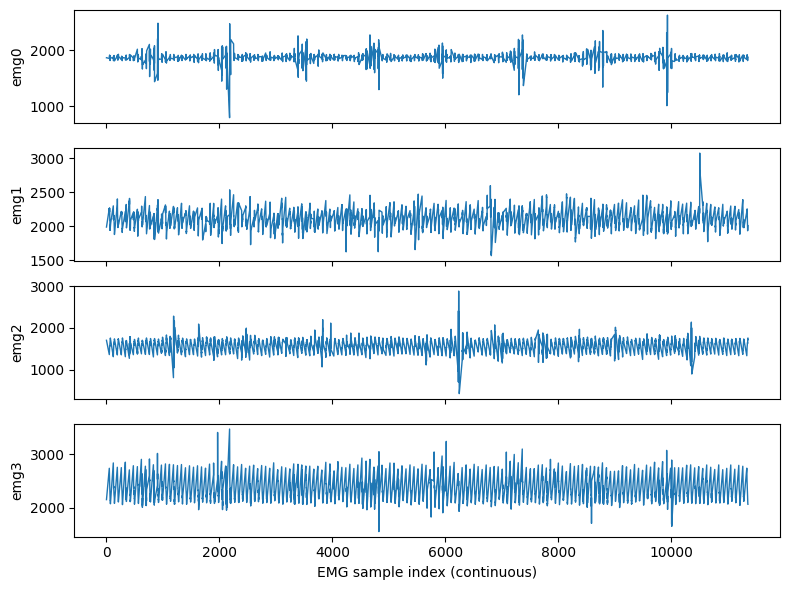

In [316]:
visualization_by_index(csv_path="/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/4-5_LAtime_EMG_clean.csv",
                       t_start="2026-04-09 20:07:24.201",
                       t_end="2026-04-09 20:07:49.861"
                    )

### task234

In [63]:
def remove_relay_artifacts_by_burst_edges2(
    df,
    emg_cols=("emg0","emg1","emg2","emg3"),
    time_col="device_us",
    modality_col=None,             # <-- auto-detect if None
    emg_tag="EMG",
    gap_us=8000,                   # threshold to detect a new EMG burst
    drop_head=3,                   # drop first N samples in each burst
    drop_tail=0,                   # drop last N samples
    interp=True,
):
    # ---- pick modality column ----
    if modality_col is None:
        if "modality" in df.columns:
            modality_col = "modality"
        elif "src" in df.columns:
            modality_col = "src"
        else:
            raise KeyError("No modality column found. Expected 'modality' or 'src'.")

    # ---- validate time column ----
    if time_col not in df.columns:
        raise KeyError(f"Time column '{time_col}' not found. Available: {list(df.columns)}")

    # ---- EMG only ----
    emg = df[df[modality_col].astype(str).str.strip().str.upper() == emg_tag.upper()].copy()

    # numeric conversion
    emg[time_col] = pd.to_numeric(emg[time_col], errors="coerce")
    for c in emg_cols:
        if c not in emg.columns:
            raise KeyError(f"EMG column '{c}' not found in df.")
        emg[c] = pd.to_numeric(emg[c], errors="coerce")

    emg = emg.dropna(subset=[time_col, *emg_cols]).sort_values(time_col).reset_index(drop=True)

    # detect burst starts by large time gap
    du = emg[time_col].diff().fillna(0)
    new_burst = du > gap_us
    burst_id = new_burst.cumsum()

    # position inside each burst + burst length
    pos = emg.groupby(burst_id).cumcount()
    burst_len = emg.groupby(burst_id)[time_col].transform("size")

    # mark samples to remove
    bad = (pos < drop_head) | (pos >= (burst_len - drop_tail))

    emg_clean = emg.copy()
    emg_clean.loc[bad, list(emg_cols)] = np.nan

    if interp:
        for c in emg_cols:
            emg_clean[c] = emg_clean[c].interpolate(limit_direction="both")

    return emg, emg_clean, bad


In [66]:
from pathlib import Path
import pandas as pd

# ---- your functions must already be defined/imported ----
# from your_module import remove_relay_artifacts_by_burst_edges, plot_emg_index

# =========================
# CONFIG: set your folders
# =========================
in_dir  = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime")
out_dir = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg")

out_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Find files starting with "1"
# =========================
patterns = ["2-*.csv", "3-*.csv", "4-*.csv", "5-*.csv"]
csv_files = sorted({p for pat in patterns for p in in_dir.glob(pat) if p.is_file()})

print(f"Found {len(csv_files)} file(s) starting with '1' in: {in_dir}")

# =========================
# Process each file
# =========================
for csv_path in csv_files:
    try:
        print("\nProcessing:", csv_path.name)

        df = pd.read_csv(csv_path)

        emg_raw, emg_clean, bad = remove_relay_artifacts_by_burst_edges2(
            df,
            gap_us=16_000,
            drop_head=50,
            drop_tail=0,
            interp=True,
        )

        # Optional: plot per file (comment out if too many files)
        # plot_emg_index(emg_clean, f"{csv_path.stem}: EMG clean")

        out_csv = out_dir / f"{csv_path.stem}_EMG_clean.csv"
        emg_clean.to_csv(out_csv, index=False)

        print("  Saved:", out_csv)
        print("  Rows:", len(emg_clean), " | Cols:", len(emg_clean.columns))

    except Exception as e:
        print("  ERROR on", csv_path.name, "->", repr(e))

print("\nDone.")


Found 34 file(s) starting with '1' in: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/raw_emg_angle/emg_LAtime

Processing: 2-0_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/2-0_LAtime_EMG_clean.csv
  Rows: 1737  | Cols: 16

Processing: 2-10_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/2-10_LAtime_EMG_clean.csv
  Rows: 82635  | Cols: 16

Processing: 2-1_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/2-1_LAtime_EMG_clean.csv
  Rows: 116637  | Cols: 16

Processing: 2-2_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/2-2_LAtime_EMG_clean.csv
  Rows: 109376  | Cols: 16

Processing: 2-3_LAtime.csv
  Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/2-3_LAtime_EMG_clean.csv
  Rows: 68277  | Cols: 16

Processing: 2-4_LAtime.csv
  Saved: /Users/mmz

EMG rows: 32961


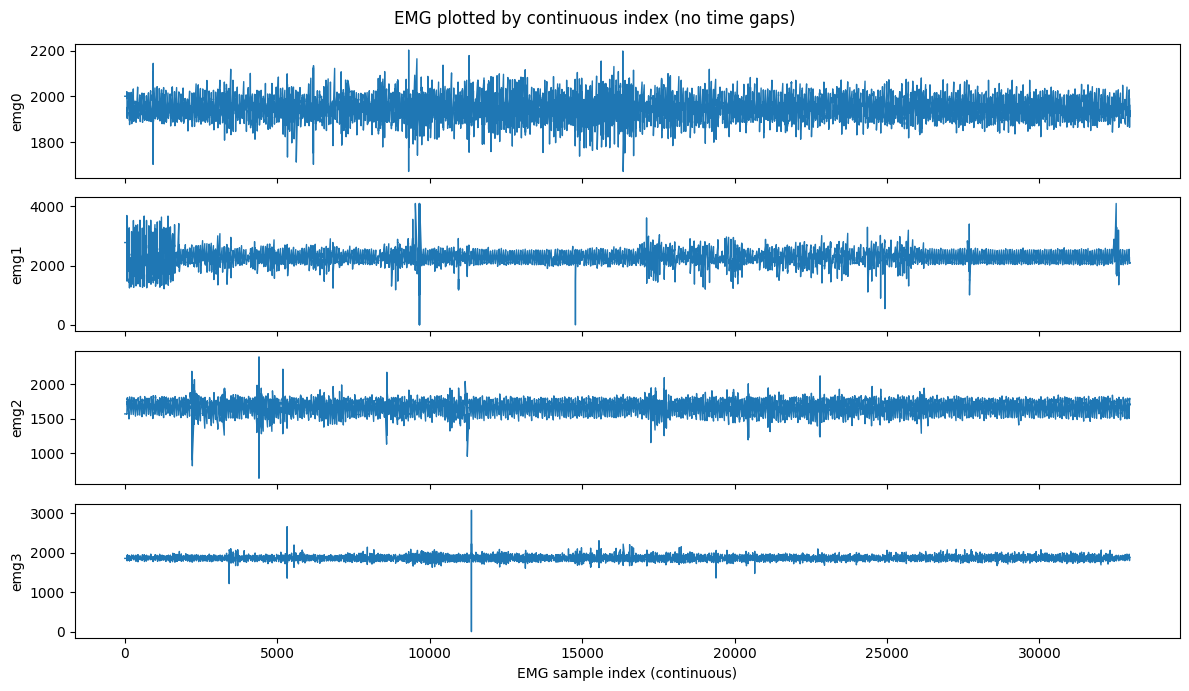

In [79]:
visualization_by_index("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/5-0_LAtime_EMG_clean.csv")

# Envelope extraction

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, List

# ---------- your existing helper (must exist) ----------
def clamp_to_baseline_window(series: pd.Series,
                             low: float,
                             high: float,
                             window_ms: float,
                             baseline: Optional[float] = None) -> pd.Series:
    """
    Clamp to baseline in TIME-WINDOWS around out-of-range values.

    - Any sample with value < low or > high is considered 'bad'.
    - We then expand this 'bad' mask by ±window_ms in time.
    - All samples in that expanded region are set to baseline.

    series     : EMG signal, indexed by DateTimeIndex
    low, high  : acceptable range
    window_ms  : half-window size (ms) around bad samples
    baseline   : if None, computed as median of in-range samples
    """
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("clamp_to_baseline_window: series.index must be DateTimeIndex")

    s = pd.to_numeric(series, errors="coerce").astype(float).copy()
    idx = s.index.to_numpy()
    vals = s.values

    # Compute baseline if not given
    if baseline is None:
        in_range_mask = (~np.isnan(vals)) & (vals >= low) & (vals <= high)
        if in_range_mask.any():
            baseline = float(np.nanmedian(vals[in_range_mask]))
        else:
            # No good reference → do nothing
            return s

    # Basic 'bad' mask: out-of-range samples
    bad = (~np.isnan(vals)) & ((vals < low) | (vals > high))
    if not bad.any():
        return s  # nothing to clamp

    # Estimate sampling interval (s)
    if len(idx) < 2:
        return s
    dts = np.diff(idx).astype("timedelta64[ns]").astype(np.int64) / 1e9  # seconds
    dt = float(np.median(dts)) if len(dts) > 0 else window_ms / 1000.0
    if dt <= 0:
        dt = window_ms / 1000.0

    # Convert window_ms to radius in samples
    radius = int(np.ceil((window_ms / 1000.0) / dt))
    radius = max(radius, 1)

    # Morphological dilation: expand 'bad' mask by ±radius samples
    bad_int = bad.astype(int)
    kernel = np.ones(2 * radius + 1, dtype=int)
    expanded = np.convolve(bad_int, kernel, mode="same") > 0

    # Clamp everything in expanded region to baseline
    vals[expanded] = baseline

    return pd.Series(vals, index=series.index, name=series.name)

# ---------- utils ----------
def estimate_fs_from_timestamps(ts: pd.Series):
    ts = pd.to_datetime(ts, errors="coerce")
    dt = ts.diff().dt.total_seconds().dropna()
    dt = dt[dt > 0]
    if len(dt) == 0:
        return np.nan
    return 1.0 / np.median(dt)

def plot_step(df_long, value_col, title, channels=(0,1,2,3), max_points=10**12):
    """
    Plot value_col for each channel as 4 subplots.
    Downsamples for speed.
    """
    fig, axs = plt.subplots(4, 1, figsize=(18, 8), sharex=False)
    fig.suptitle(title, y=0.98)

    for i, ch in enumerate(channels):
        d = df_long[df_long["emg_ch"] == ch].copy()
        if d.empty:
            axs[i].set_title(f"ch{ch} (no data)")
            continue

        d = d.sort_values("timestamp")
        x = d["timestamp"].to_numpy()
        y = pd.to_numeric(d[value_col], errors="coerce").to_numpy(dtype=float)

        ok = np.isfinite(y) & pd.notnull(x)
        x = x[ok]
        y = y[ok]

        # downsample
        if len(y) > max_points:
            step = int(np.ceil(len(y) / max_points))
            x = x[::step]
            y = y[::step]

        axs[i].plot(x, y, lw=0.8)
        axs[i].set_ylabel(f"ch{ch}")
        axs[i].grid(alpha=0.25)

    axs[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

# ---------- Step 0: wide -> long ----------
def wide_emg_csv_to_long(
    csv_path,
    time_col_candidates=("timestamp_la", "timestamp", "host_time_s"),
    emg_cols=("emg0", "emg1", "emg2", "emg3"),
    meta_cols=("host_time_s","host_rel_s","device_us","device_s","trial_id","label","mark","relay_on")
):
    df = pd.read_csv(csv_path)

    # ---------- label fallback: label <- label_id when needed ----------
    if "label_id" in df.columns:
        if "label" not in df.columns:
            df["label"] = df["label_id"]
        else:
            # treat empty string as missing
            df["label"] = df["label"].replace("", np.nan)
            df["label"] = df["label"].where(df["label"].notna(), df["label_id"])

    # ---------- time parsing ----------
    time_col = next((c for c in time_col_candidates if c in df.columns), None)
    if time_col is None:
        raise KeyError(f"No time column found. Columns: {list(df.columns)}")

    if time_col == "host_time_s":
        df["host_time_s"] = pd.to_numeric(df["host_time_s"], errors="coerce")
        df["timestamp"] = pd.to_datetime(df["host_time_s"], unit="s", errors="coerce")
    else:
        df["timestamp"] = pd.to_datetime(df[time_col], errors="coerce")

    df = df.dropna(subset=["timestamp"]).copy()

    # ---------- modality filter ----------
    if "modality" in df.columns:
        df = df[df["modality"].astype(str).str.upper() == "EMG"].copy()
    elif "src" in df.columns:
        df = df[df["src"].astype(str).str.upper() == "EMG"].copy()

    keep_meta = [c for c in meta_cols if c in df.columns]
    use_emg_cols = [c for c in emg_cols if c in df.columns]

    long = df.melt(
        id_vars=["timestamp", *keep_meta],
        value_vars=use_emg_cols,
        var_name="emg_ch",
        value_name="emg_val"
    )

    long["emg_ch"] = long["emg_ch"].astype(str).str.replace("emg", "", regex=False)
    long["emg_ch"] = pd.to_numeric(long["emg_ch"], errors="coerce")
    long["emg_val"] = pd.to_numeric(long["emg_val"], errors="coerce")

    long = long.dropna(subset=["emg_ch", "emg_val", "timestamp"]).copy()
    long["emg_ch"] = long["emg_ch"].astype(int)
    long = long.sort_values(["emg_ch", "timestamp"]).reset_index(drop=True)
    return long


# ---------- Step 1: rectification (baseline removal then abs) ----------
def rectification_long(emg_long: pd.DataFrame,
                       channels=(0,1,2,3),
                       in_col="emg_val",
                       out_col="emg_rect",
                       dc_method="median"):
    df = emg_long.copy()
    df[in_col] = pd.to_numeric(df[in_col], errors="coerce")
    df[out_col] = np.nan

    for ch in channels:
        m = df["emg_ch"] == ch
        x = df.loc[m, in_col].to_numpy(dtype=float)
        dc = np.nanmedian(x) if dc_method == "median" else np.nanmean(x)
        df.loc[m, out_col] = np.abs(x - dc)
    return df

# ---------- Step 2: baseline-after-rectification + despike (clamp windows) ----------
def _baseline_from_rectified(x, q=0.2):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    thr = np.quantile(x, q)
    low_part = x[x <= thr]
    return float(np.median(low_part)) if low_part.size else float(np.median(x))

def _auto_high_from_mad(x, base, k=20.0, clip_q=0.95):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0 or not np.isfinite(base):
        return np.nan
    cap = np.quantile(x, clip_q)
    x2 = x[x <= cap]
    if x2.size == 0:
        x2 = x
    med = np.median(x2)
    mad = np.median(np.abs(x2 - med))
    sigma = 1.4826 * mad
    if not np.isfinite(sigma) or sigma == 0:
        sigma = np.std(x2) if np.std(x2) > 0 else 1.0
    return float(base + k * sigma)

def despike_after_rectification(emg_long: pd.DataFrame,
                                rect_col="emg_rect",
                                out_col="emg_rect_clean",
                                channels=(0,1,2,3),
                                window_ms=15.0,
                                baseline_q=0.2,
                                high_mode="auto_mad",  # "auto_mad" | "relative" | "absolute"
                                high_k=20.0,
                                high_rel=800.0,
                                high_abs=3000.0):
    df = emg_long.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df[out_col] = np.nan

    for ch in channels:
        m = df["emg_ch"] == ch
        ch_df = df.loc[m, ["timestamp", rect_col]].dropna().copy()
        if ch_df.empty:
            continue

        s = ch_df.set_index("timestamp")[rect_col].astype(float)
        base = _baseline_from_rectified(s.values, q=baseline_q)

        if high_mode == "auto_mad":
            high = _auto_high_from_mad(s.values, base, k=high_k)
        elif high_mode == "relative":
            high = base + high_rel
        elif high_mode == "absolute":
            high = high_abs
        else:
            raise ValueError("high_mode must be 'auto_mad', 'relative', or 'absolute'")

        s_clean = clamp_to_baseline_window(
            s,
            low=-np.inf,    # only care high spikes for rectified
            high=high,
            window_ms=window_ms,
            baseline=base
        )

        df.loc[m, out_col] = s_clean.reindex(df.loc[m, "timestamp"]).values

    return df

# ---------- Step 3: RMS envelope from cleaned rectified ----------
def rms_envelope_from_rectified(emg_long: pd.DataFrame,
                               rect_col="emg_rect_clean",
                               out_rms="env_rms",
                               out_smooth="env_rms_smooth",
                               channels=(0,1,2,3),
                               rms_win_ms=50,
                               smooth_win_ms=200):
    df = emg_long.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df[out_rms] = np.nan
    df[out_smooth] = np.nan

    for ch in channels:
        m = df["emg_ch"] == ch
        ch_df = df.loc[m, ["timestamp", rect_col]].dropna().copy()
        if ch_df.empty:
            continue

        ch_df = ch_df.sort_values("timestamp")
        t = ch_df["timestamp"]
        x = ch_df[rect_col].astype(float).to_numpy()

        fs = estimate_fs_from_timestamps(t)
        if not np.isfinite(fs) or fs <= 0:
            continue

        win = max(1, int(rms_win_ms * 1e-3 * fs))
        sm  = max(1, int(smooth_win_ms * 1e-3 * fs))

        rms = np.sqrt(np.convolve(x**2, np.ones(win)/win, mode="same"))
        rms_s = np.convolve(rms, np.ones(sm)/sm, mode="same")

        df.loc[m, out_rms] = rms
        df.loc[m, out_smooth] = rms_s

    return df


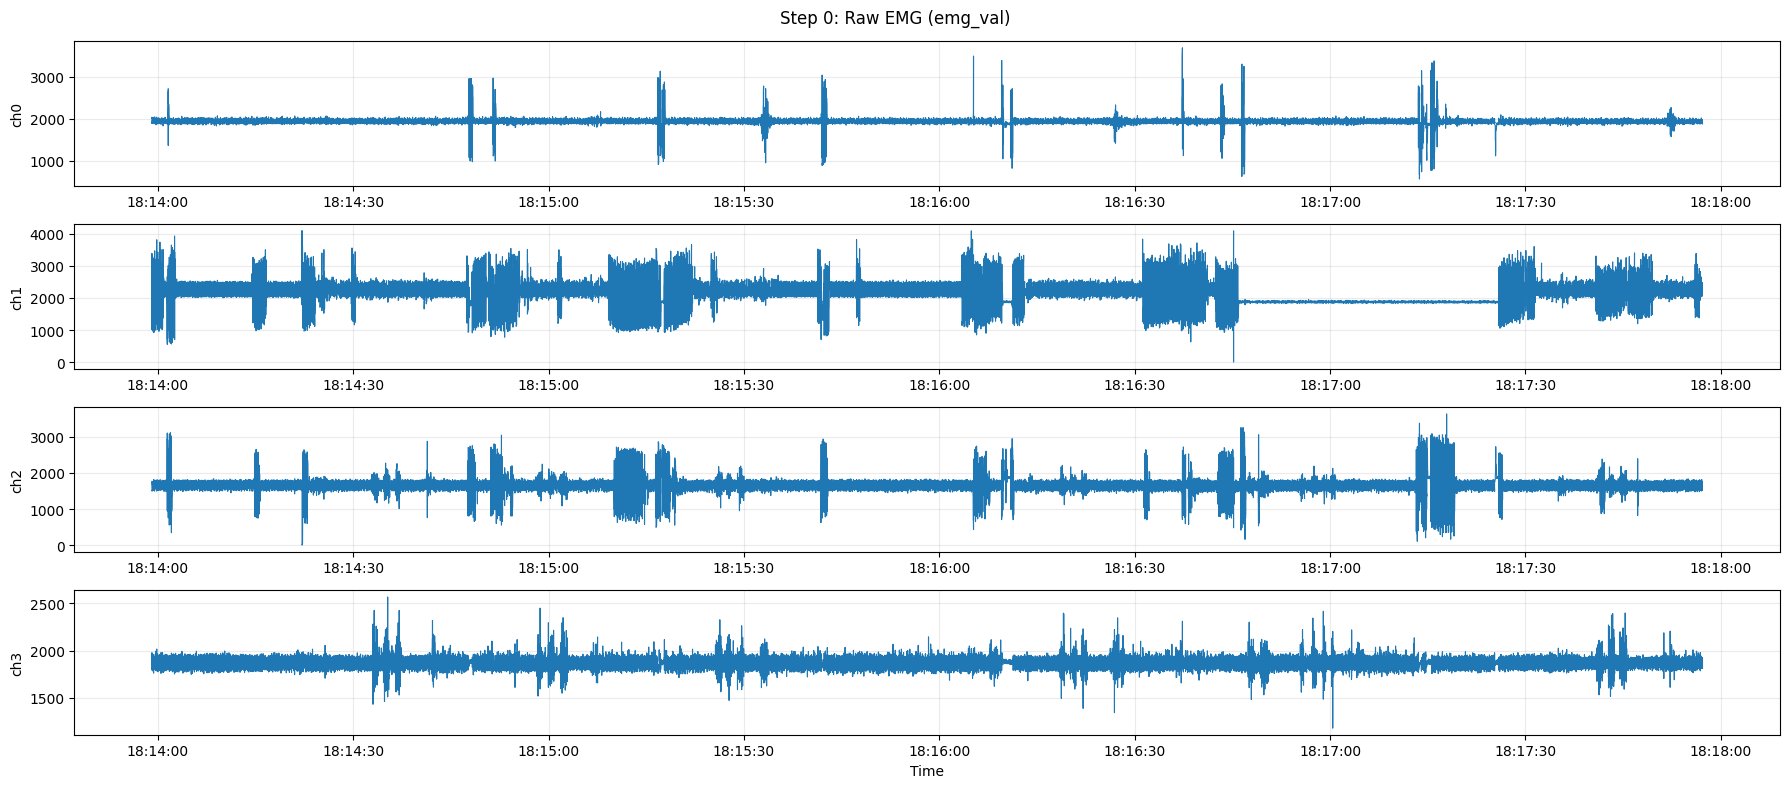

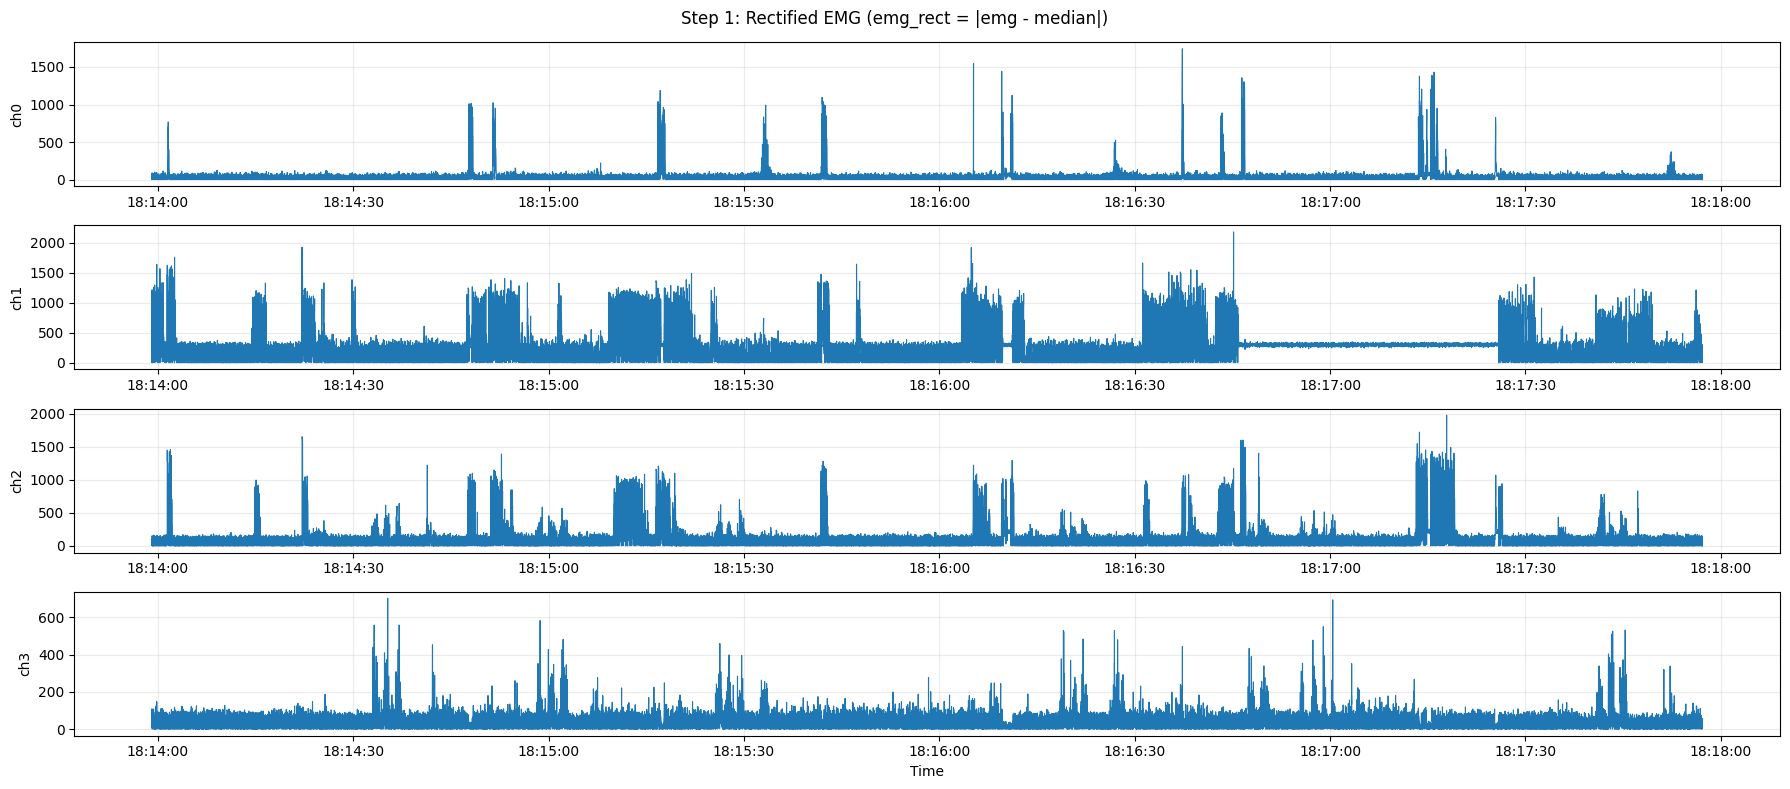

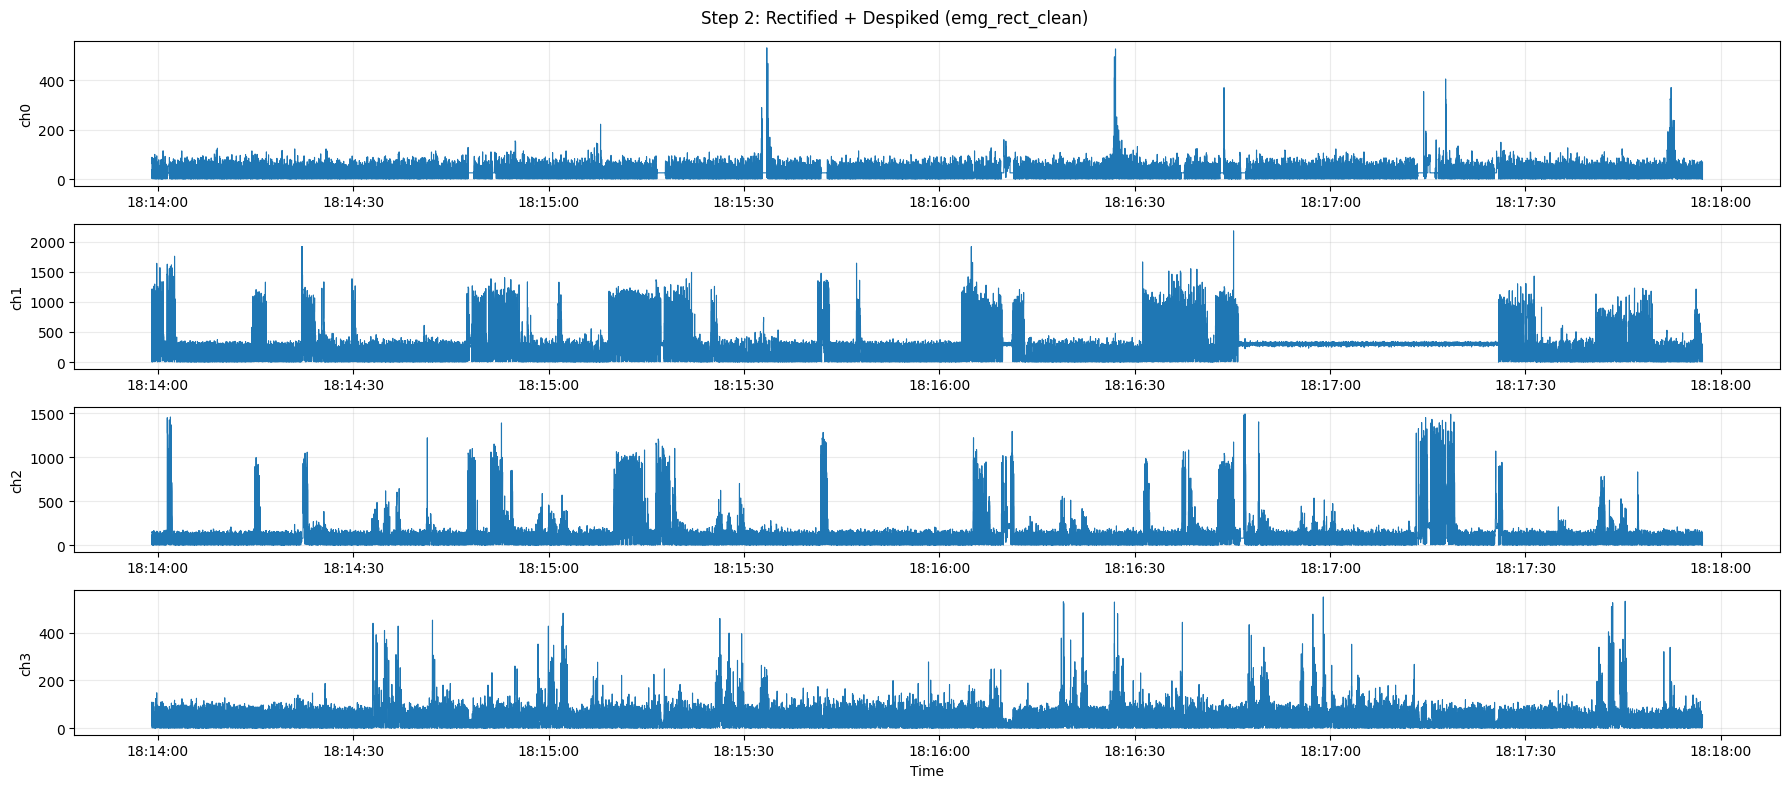

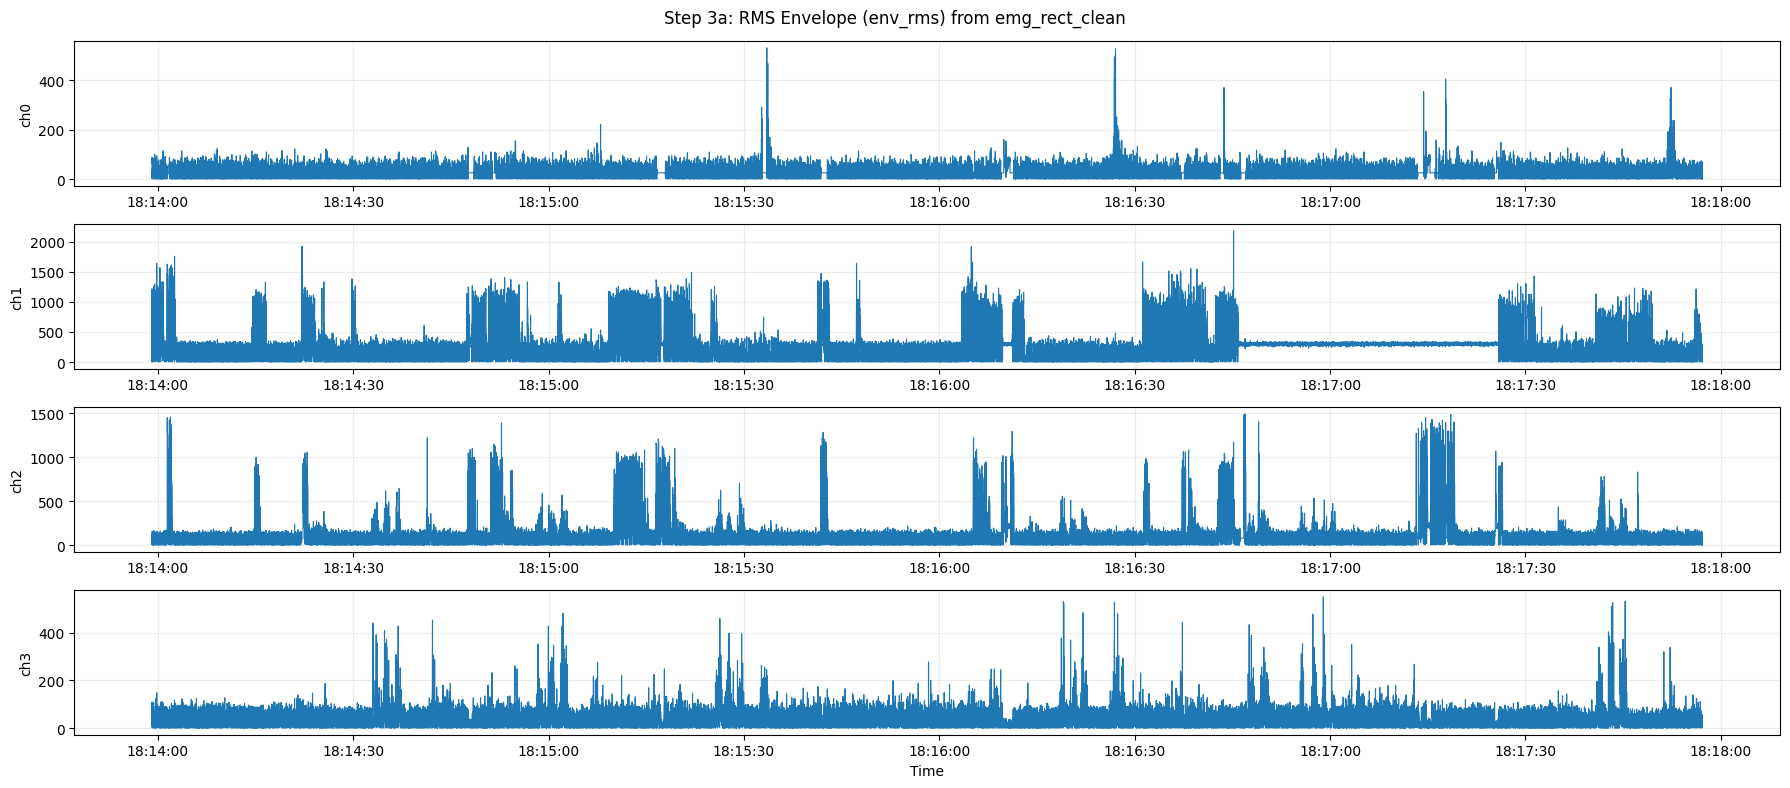

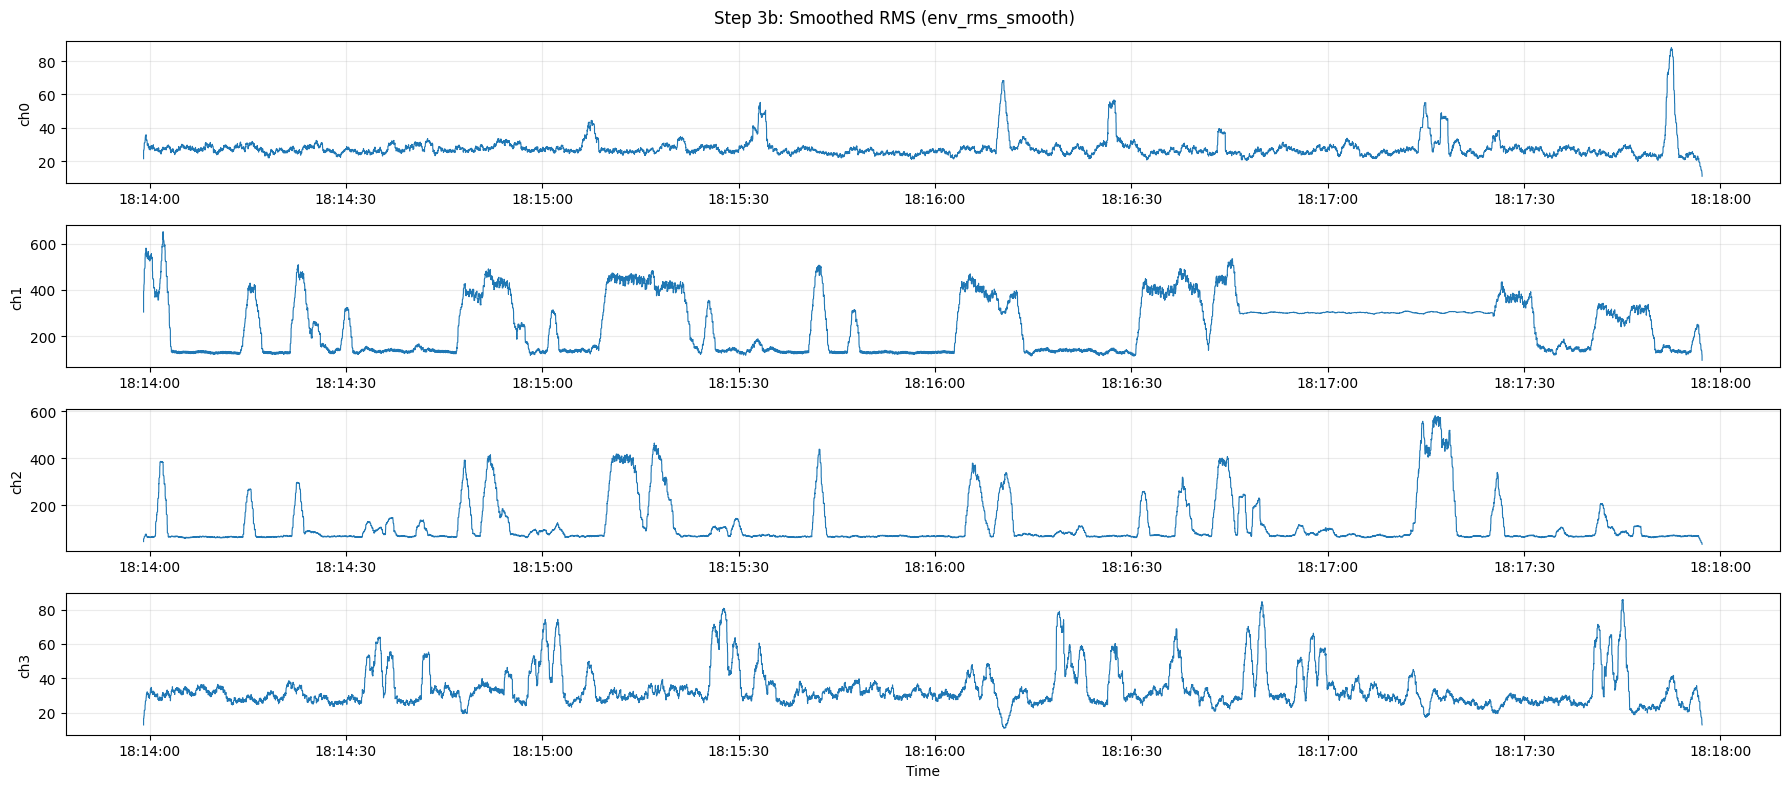

In [285]:
# =========================
# RUN PIPELINE
# =========================
csv_path = "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-1_LAtime_EMG_clean.csv"
channels = (0,1,2,3)

emg_long = wide_emg_csv_to_long(csv_path)

# Plot raw (optional)
plot_step(emg_long, "emg_val", "Step 0: Raw EMG (emg_val)", channels=channels)

# Step 1: Rectification + plot
emg_long = rectification_long(emg_long, channels=channels, in_col="emg_val", out_col="emg_rect", dc_method="median")
plot_step(emg_long, "emg_rect", "Step 1: Rectified EMG (emg_rect = |emg - median|)", channels=channels)

# Step 2: Despike after rectification + plot
emg_long = despike_after_rectification(
    emg_long,
    rect_col="emg_rect",
    out_col="emg_rect_clean",
    channels=channels,
    window_ms=1,
    baseline_q=1,
    high_mode="auto_mad",  # try "relative" if you prefer fixed delta above baseline
    high_k=25
)
plot_step(emg_long, "emg_rect_clean", "Step 2: Rectified + Despiked (emg_rect_clean)", channels=channels)

# Step 3: RMS envelope + plot
emg_long = rms_envelope_from_rectified(
    emg_long,
    rect_col="emg_rect_clean",
    channels=channels,
    rms_win_ms=0,
    smooth_win_ms=10
)
plot_step(emg_long, "env_rms", "Step 3a: RMS Envelope (env_rms) from emg_rect_clean", channels=channels)
plot_step(emg_long, "env_rms_smooth", "Step 3b: Smoothed RMS (env_rms_smooth)", channels=channels)

In [ ]:
import numpy as np
import pandas as pd

def save_emg_long_as_wide_csv_v2(
    emg_long: pd.DataFrame,
    out_csv_path: str,
    value_col: str = "emg_rect_clean",
    channels=(0,1,2,3),
    timestamp_col: str = "timestamp",
    meta_cols=("trial_id","label","mark","host_rel_s","device_s"),
):
    df = emg_long.copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

    # ---------- label fallback inside long (safety net) ----------
    if "label_id" in df.columns:
        if "label" not in df.columns:
            df["label"] = df["label_id"]
        else:
            df["label"] = df["label"].replace("", np.nan)
            df["label"] = df["label"].where(df["label"].notna(), df["label_id"])

    # keep only meta cols that exist (create missing ones)
    meta_cols = list(meta_cols)
    for c in meta_cols:
        if c not in df.columns:
            df[c] = np.nan

    # 1) meta per timestamp (first non-null row)
    df_meta = (
        df[[timestamp_col, *meta_cols]]
        .sort_values(timestamp_col)
        .groupby(timestamp_col, dropna=False, as_index=False)
        .first()
    )

    # 2) emg wide per timestamp
    df_emg = (
        df.pivot_table(
            index=timestamp_col,
            columns="emg_ch",
            values=value_col,
            aggfunc="first",
        )
        .reset_index()
    )

    rename_map = {ch: f"emg{int(ch)}" for ch in channels}
    df_emg = df_emg.rename(columns=rename_map)

    for ch in channels:
        col = f"emg{int(ch)}"
        if col not in df_emg.columns:
            df_emg[col] = np.nan

    wide = df_meta.merge(df_emg, on=timestamp_col, how="left")

    if "mark" in wide.columns:
        wide["mark"] = wide["mark"].fillna("")

    out_cols = [timestamp_col, *meta_cols, *[f"emg{int(ch)}" for ch in channels]]
    wide = wide[out_cols].sort_values(timestamp_col).reset_index(drop=True)

    wide.to_csv(out_csv_path, index=False, date_format="%Y-%m-%d %H:%M:%S.%f")
    print(f"Saved: {out_csv_path}  rows={len(wide)}")
    return wide

wide_saved = save_emg_long_as_wide_csv_v2(
    emg_long,
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/processed_emg2/4-5.csv",
    value_col="emg_rect_clean"
)



Saved: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/processed_emg/1-1.csv  rows=105540


# Concatenate emg files and plot

Found 41 files in: /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/processed_emg
 - 1-0.csv
 - 1-1.csv
 - 1-10.csv
 - 1-2.csv
 - 1-3.csv
 - 1-4.csv
 - 1-5.csv
 - 1-6.csv
 - 1-7.csv
 - 1-8.csv
 ... +31 more


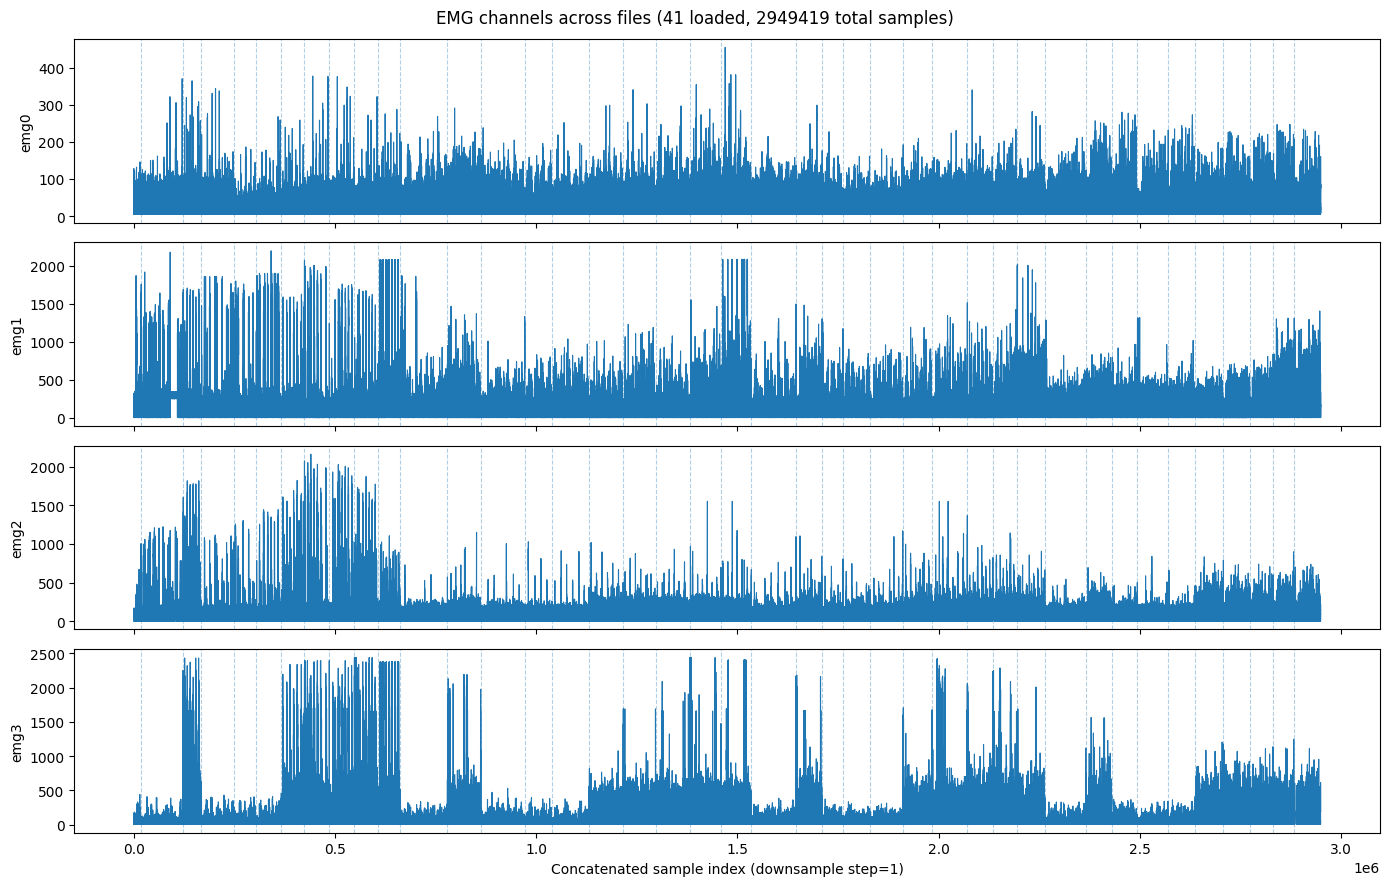

In [262]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Drop-in cell: plot EMG channels across many files in a directory (4 subplots: emg0–emg3)
# - Works for CSV/TSV/TXT with headers containing emg0..emg3 (case-insensitive).
# - If a "modality" column exists, it will auto-filter to EMG rows.
# - Robust to different time columns; concatenates by sample index for reliability.
#
# ✅ Set DATA_DIR to your folder and run. You’ll get one figure with 4 subplots.

# =========================
# CONFIG (EDIT THIS)
# =========================
DATA_DIR = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/processed_emg")   # <-- change me

# Optional: file extensions/patterns to include
GLOB_PATTERNS = ["*.csv"]

# Expected EMG channels (will match case-insensitively; also supports emg_0, EMG0, etc.)
TARGET_EMG_COLS = ["emg0", "emg1", "emg2", "emg3"]

# If total points are huge, downsample for plotting speed (keeps overall shape)
MAX_PLOT_POINTS = 250_0000000000

# =========================
# Helpers
# =========================
def _read_table(path: Path) -> pd.DataFrame:
    """Read CSV/TSV/TXT robustly (auto-detect separator where possible)."""
    suffix = path.suffix.lower()
    if suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    # sep=None lets pandas sniff delimiter with python engine
    return pd.read_csv(path, sep=None, engine="python")

def _normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

def _find_emg_cols(df: pd.DataFrame):
    """
    Return a mapping {target_name: actual_col_name} for emg0..emg3.
    Accepts variations like emg_0, emg 0, EMG0, etc.
    """
    cols = list(df.columns)
    mapping = {}
    for t in TARGET_EMG_COLS:
        # preferred exact
        if t in df.columns:
            mapping[t] = t
            continue
        # allow variants like emg_0, emg 0
        idx = t.replace("emg", "")
        candidates = [
            f"emg_{idx}", f"emg {idx}", f"emg-{idx}", f"emg{idx}",
            f"ch{idx}", f"channel{idx}", f"emgch{idx}"
        ]
        hit = next((c for c in candidates if c in df.columns), None)
        if hit is not None:
            mapping[t] = hit
            continue
        # fallback: any column that ends with that index and contains 'emg'
        hit = next((c for c in cols if ("emg" in c and c.rstrip().endswith(idx))), None)
        if hit is not None:
            mapping[t] = hit
    return mapping

def _extract_emg(df_raw: pd.DataFrame, src_name: str):
    """
    Extract emg0..emg3 from one file as a (N,4) float array.
    """
    df = _normalize_cols(df_raw)

    # Filter to EMG rows if modality exists
    if "modality" in df.columns:
        df = df[df["modality"].astype(str).str.lower().eq("emg")].copy()

    mapping = _find_emg_cols(df)
    missing = [c for c in TARGET_EMG_COLS if c not in mapping]
    if missing:
        raise ValueError(f"{src_name}: missing EMG columns {missing}. Found cols: {list(df.columns)[:30]}...")

    # Numeric conversion + clean
    for t, c in mapping.items():
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=[mapping[t] for t in TARGET_EMG_COLS])

    X = np.column_stack([df[mapping[t]].to_numpy(dtype=float) for t in TARGET_EMG_COLS])
    return X

import numpy as np
import pandas as pd

def hampel_despike_1d(x, win=101, n_sig=6.0):
    """
    Rolling median/MAD outlier removal.
    Replaces outliers with NaN (you can interpolate later).
    """
    s = pd.Series(x.astype(float))
    med = s.rolling(win, center=True, min_periods=1).median()
    mad = (s - med).abs().rolling(win, center=True, min_periods=1).median()
    sigma = 1.4826 * mad
    out = (s - med).abs() > (n_sig * sigma.replace(0, np.nan))
    y = s.copy()
    y[out] = np.nan
    return y.to_numpy(), out.to_numpy()

def despike_emg_matrix(X, adc_min=0, adc_max=4095, rail_margin=5,
                       hampel_win=101, hampel_nsig=6.0, interp=True):
    """
    X: (N,4) for emg0..emg3
    - Remove rail hits near adc_min/adc_max
    - Hampel despike for remaining spikes
    - Interpolate NaNs to keep continuity
    """
    X = X.astype(float).copy()
    bad_all = np.zeros_like(X, dtype=bool)

    for ch in range(X.shape[1]):
        x = X[:, ch]

        # 1) rail-hit mask (common cause of tall spikes)
        bad = (x <= adc_min + rail_margin) | (x >= adc_max - rail_margin)

        # 2) Hampel (rolling) for isolated spikes
        x2 = x.copy()
        x2[bad] = np.nan
        y, out = hampel_despike_1d(np.nan_to_num(x2, nan=np.nanmedian(x2)), win=hampel_win, n_sig=hampel_nsig)

        # combine masks
        bad = bad | np.isnan(y)

        # 3) fill (optional)
        if interp:
            y = pd.Series(y).interpolate(limit_direction="both").to_numpy()

        X[:, ch] = y
        bad_all[:, ch] = bad

    return X, bad_all

# =========================
# Collect files
# =========================
files = []
if DATA_DIR.exists():
    for pat in GLOB_PATTERNS:
        files.extend(sorted(DATA_DIR.glob(pat)))
files = sorted(set(files))

# If no files are available here (e.g., running in this chat sandbox), create a small demo.
if len(files) == 0:
    demo_dir = Path("/mnt/data/emg_demo")
    demo_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(0)
    fs = 200
    for k in range(3):
        n = 3000 + 800 * k
        t = np.arange(n) / fs
        emg0 = 0.2*np.sin(2*np.pi*3*t) + 0.05*rng.standard_normal(n)
        emg1 = 0.15*np.sin(2*np.pi*5*t + 0.7) + 0.05*rng.standard_normal(n)
        emg2 = 0.10*np.sin(2*np.pi*7*t + 1.2) + 0.05*rng.standard_normal(n)
        emg3 = 0.18*np.sin(2*np.pi*4*t + 2.0) + 0.05*rng.standard_normal(n)
        df_demo = pd.DataFrame({"emg0": emg0, "emg1": emg1, "emg2": emg2, "emg3": emg3})
        df_demo.to_csv(demo_dir / f"demo_{k:02d}.csv", index=False)
    DATA_DIR = demo_dir
    files = sorted(DATA_DIR.glob("*.csv"))
    print(f"[Demo] No files found at your DATA_DIR. Created demo files in: {DATA_DIR}")

print(f"Found {len(files)} files in: {DATA_DIR}")
for f in files[:10]:
    print(" -", f.name)
if len(files) > 10:
    print(f" ... +{len(files)-10} more")

# =========================
# Load + concatenate
# =========================
chunks = []
file_names = []
boundaries = [0]  # sample index where each file starts in the concatenated stream

for fp in files:
    try:
        df = _read_table(fp)
        X = _extract_emg(df, fp.name)  # (N,4)
        X, bad = despike_emg_matrix(
                            X,
                            adc_min=0, adc_max=4095,      # change if your ADC range differs
                            rail_margin=5,                # increase to 10–20 if rails are “fat”
                            hampel_win=101,               # try 51 / 101 / 201
                            hampel_nsig=6.0,              # try 4–8
                            interp=True
                        )

        chunks.append(X)
        boundaries.append(boundaries[-1] + X.shape[0])
        file_names.append(fp.name)
    except Exception as e:
        print(f"[Skip] {fp.name}: {e}")

if len(chunks) == 0:
    raise RuntimeError("No usable EMG data was loaded. Check column names (emg0..emg3) and file formats.")

X_all = np.vstack(chunks)
n_total = X_all.shape[0]

# Downsample for plotting if huge
step = 1
if n_total > MAX_PLOT_POINTS:
    step = math.ceil(n_total / MAX_PLOT_POINTS)
    X_plot = X_all[::step, :]
    boundaries_plot = [b // step for b in boundaries]
else:
    X_plot = X_all
    boundaries_plot = boundaries

x = np.arange(X_plot.shape[0])

# =========================
# Plot
# =========================
fig, axs = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for i, ch in enumerate(TARGET_EMG_COLS):
    axs[i].plot(x, X_plot[:, i], linewidth=0.8)
    axs[i].set_ylabel(ch)
    for b in boundaries_plot[1:-1]:
        axs[i].axvline(b, linestyle="--", linewidth=0.8, alpha=0.35)

axs[-1].set_xlabel(f"Concatenated sample index (downsample step={step})")
fig.suptitle(f"EMG channels across files ({len(chunks)} loaded, {n_total} total samples)", y=0.98)
plt.tight_layout()
plt.show()


Using fs=1000.00 Hz  ->  rms_win=50 samples, smooth_win=200 samples


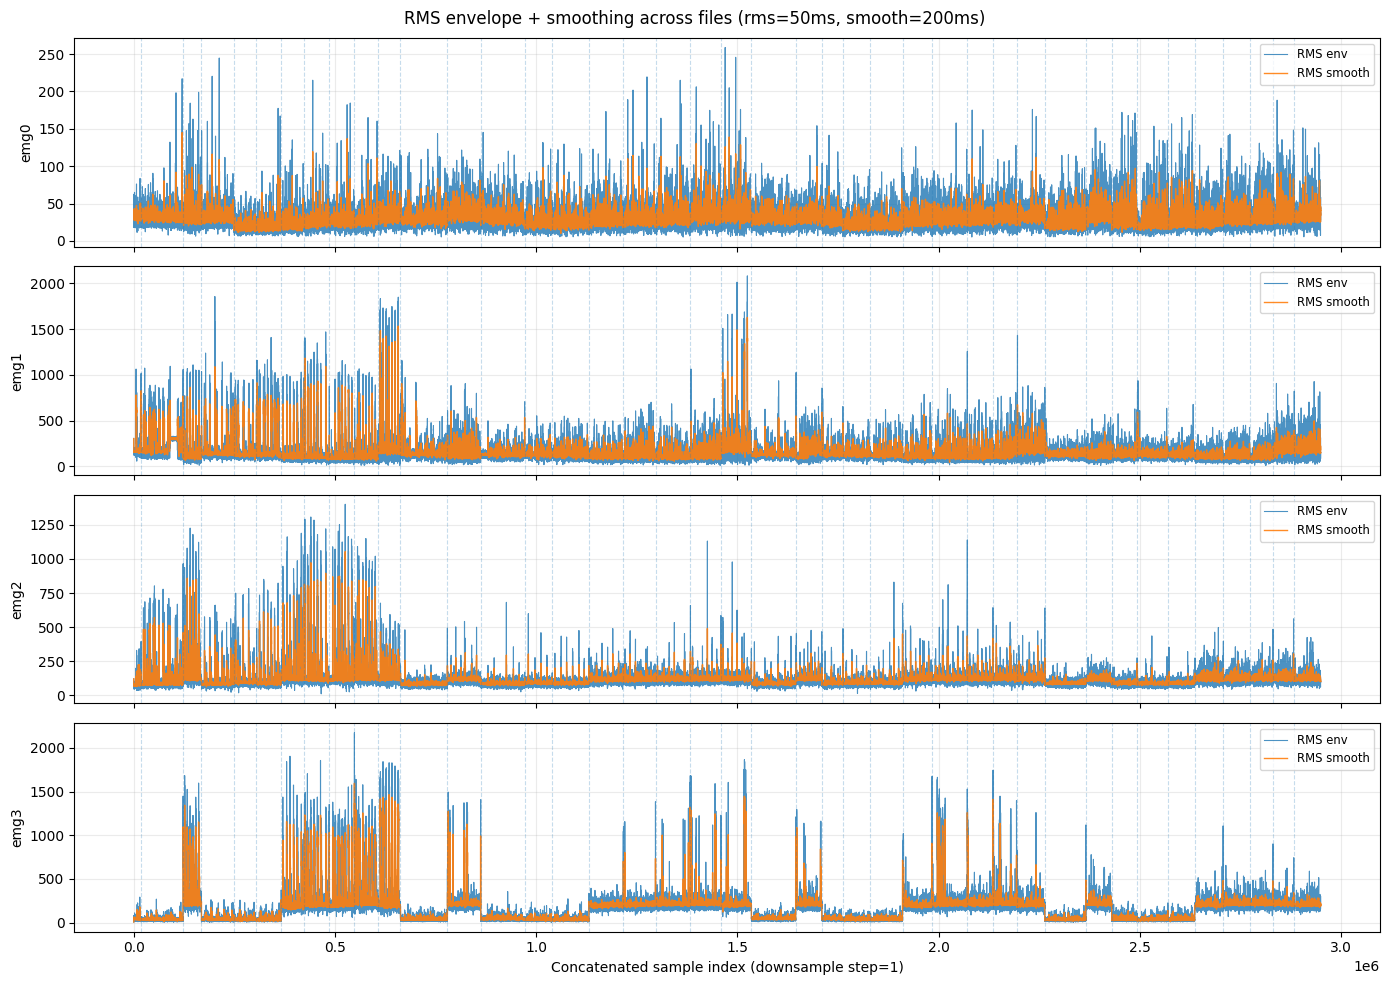

In [263]:
import numpy as np
import matplotlib.pyplot as plt

def moving_mean_same(x: np.ndarray, win: int) -> np.ndarray:
    """Fast moving average with SAME length output (edge-padded)."""
    win = int(win)
    if win <= 1:
        return x.astype(float)

    pad_left = win // 2
    pad_right = win - 1 - pad_left
    xpad = np.pad(x.astype(float), (pad_left, pad_right), mode="edge")

    c = np.cumsum(np.insert(xpad, 0, 0.0))
    y = (c[win:] - c[:-win]) / win
    return y

def rms_envelope_1d(x: np.ndarray, win: int) -> np.ndarray:
    """RMS envelope using moving mean of squared signal."""
    return np.sqrt(moving_mean_same(x**2, win))

# ===== Choose window sizes =====
# If you know your sampling rate fs (Hz), use ms windows:
fs = 1000.0   # <-- set this if you know it (your device_s looks like 0.001s step => ~1000 Hz)

rms_win_ms = 50     # typical RMS envelope window (20–100 ms)
smooth_win_ms = 200 # extra smoothing on the RMS (100–300 ms)

rms_win = max(1, int(round(rms_win_ms * 1e-3 * fs)))
smooth_win = max(1, int(round(smooth_win_ms * 1e-3 * fs)))

print(f"Using fs={fs:.2f} Hz  ->  rms_win={rms_win} samples, smooth_win={smooth_win} samples")

# ===== Compute RMS + smoothed RMS on FULL concatenated signal =====
env_rms = np.zeros_like(X_all, dtype=float)
env_smooth = np.zeros_like(X_all, dtype=float)

for ch in range(X_all.shape[1]):
    env_rms[:, ch] = rms_envelope_1d(X_all[:, ch], rms_win)
    env_smooth[:, ch] = moving_mean_same(env_rms[:, ch], smooth_win)

# ===== Downsample for plotting consistently with your existing step =====
if step > 1:
    env_rms_plot = env_rms[::step, :]
    env_smooth_plot = env_smooth[::step, :]
else:
    env_rms_plot = env_rms
    env_smooth_plot = env_smooth

# ===== Plot RMS + Smoothed RMS (4 subplots) =====
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, ch_name in enumerate(TARGET_EMG_COLS):
    axs[i].plot(x, env_rms_plot[:, i], lw=0.8, alpha=0.8, label="RMS env")
    axs[i].plot(x, env_smooth_plot[:, i], lw=1.0, alpha=0.9, label="RMS smooth")
    axs[i].set_ylabel(ch_name)
    for b in boundaries_plot[1:-1]:
        axs[i].axvline(b, linestyle="--", linewidth=0.8, alpha=0.25)
    axs[i].grid(alpha=0.25)
    axs[i].legend(loc="upper right", fontsize="small")

axs[-1].set_xlabel(f"Concatenated sample index (downsample step={step})")
fig.suptitle(f"RMS envelope + smoothing across files (rms={rms_win_ms}ms, smooth={smooth_win_ms}ms)", y=0.98)
plt.tight_layout()
plt.show()


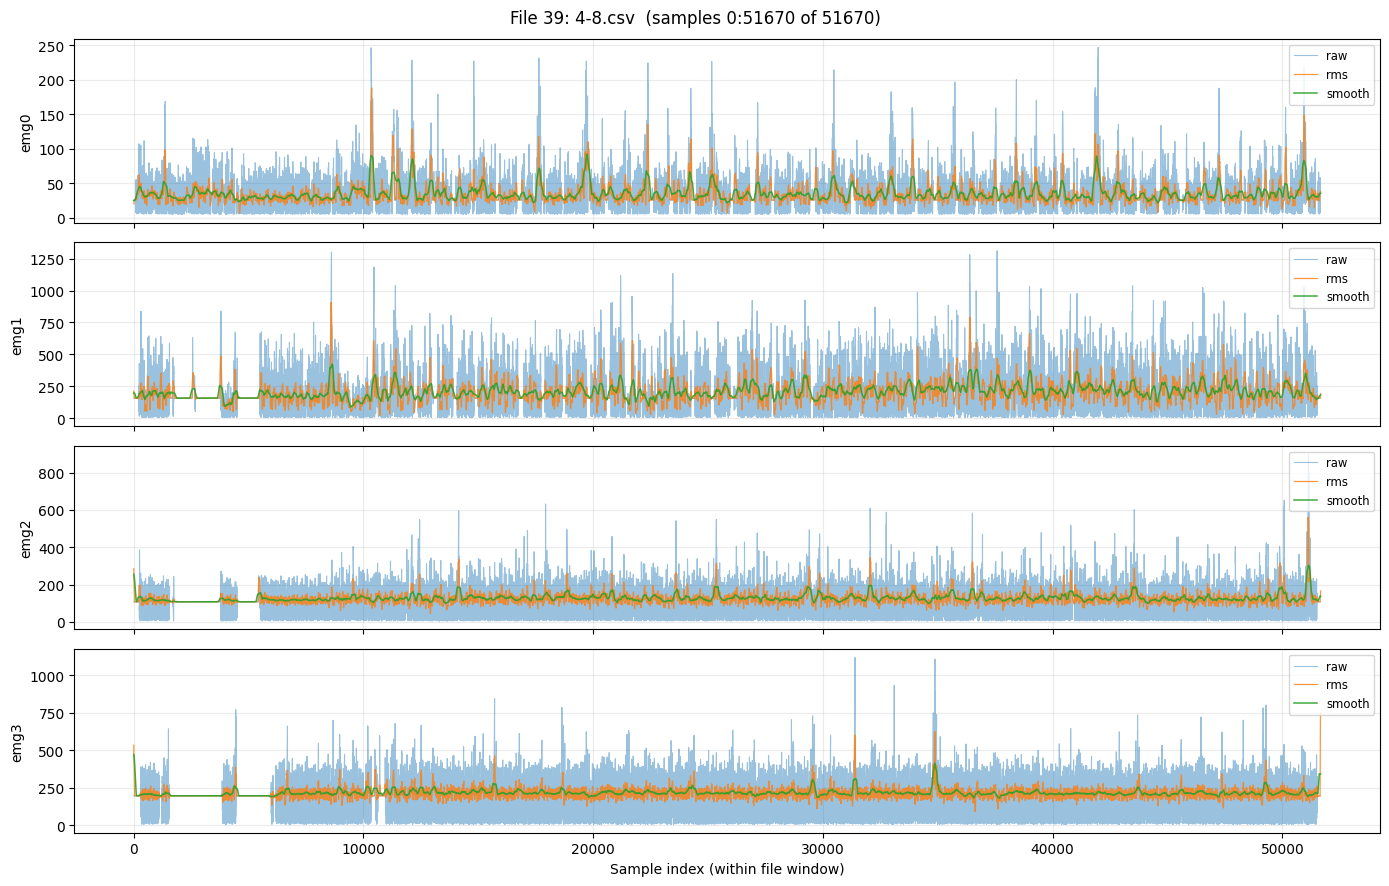

In [269]:
# Make sure you also stored file names during loading:
# Add inside your for fp in files loop:
#   file_names.append(fp.name)

def plot_one_file_from_concat(file_idx,
                              show=("raw","rms","smooth"),
                              start=None, end=None,
                              downsample=1):
    """
    View details for one file by slicing X_all/env_rms/env_smooth using boundaries.
    start/end are sample indices within THAT file.
    """
    s0 = boundaries[file_idx]
    s1 = boundaries[file_idx + 1]
    n = s1 - s0

    # window within the file
    a = 0 if start is None else int(max(0, start))
    b = n if end   is None else int(min(n, end))
    if b <= a:
        raise ValueError("Bad window: end must be > start.")

    sl = slice(s0 + a, s0 + b, int(max(1, downsample)))

    fig, axs = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    title = f"File {file_idx}: {file_names[file_idx]}  (samples {a}:{b} of {n})"
    fig.suptitle(title, y=0.98)

    xx = np.arange((b - a + downsample - 1)//downsample)

    for ch in range(4):
        if "raw" in show:
            axs[ch].plot(xx, X_all[sl, ch], lw=0.8, alpha=0.45, label="raw")
        if "rms" in show:
            axs[ch].plot(xx, env_rms[sl, ch], lw=0.9, alpha=0.8, label="rms")
        if "smooth" in show:
            axs[ch].plot(xx, env_smooth[sl, ch], lw=1.1, alpha=0.9, label="smooth")

        axs[ch].set_ylabel(f"emg{ch}")
        axs[ch].grid(alpha=0.25)
        axs[ch].legend(loc="upper right", fontsize="small")

    axs[-1].set_xlabel("Sample index (within file window)")
    plt.tight_layout()
    plt.show()

# Example:
plot_one_file_from_concat(39)
# plot_one_file_from_concat(0, start=0, end=5000, downsample=1)
# plot_one_file_from_concat(2, show=("smooth",), start=10000, end=20000)


Normalization denominators per channel:
  emg0: 144.953
  emg1: 1627.71
  emg2: 1053.93
  emg3: 1595.47


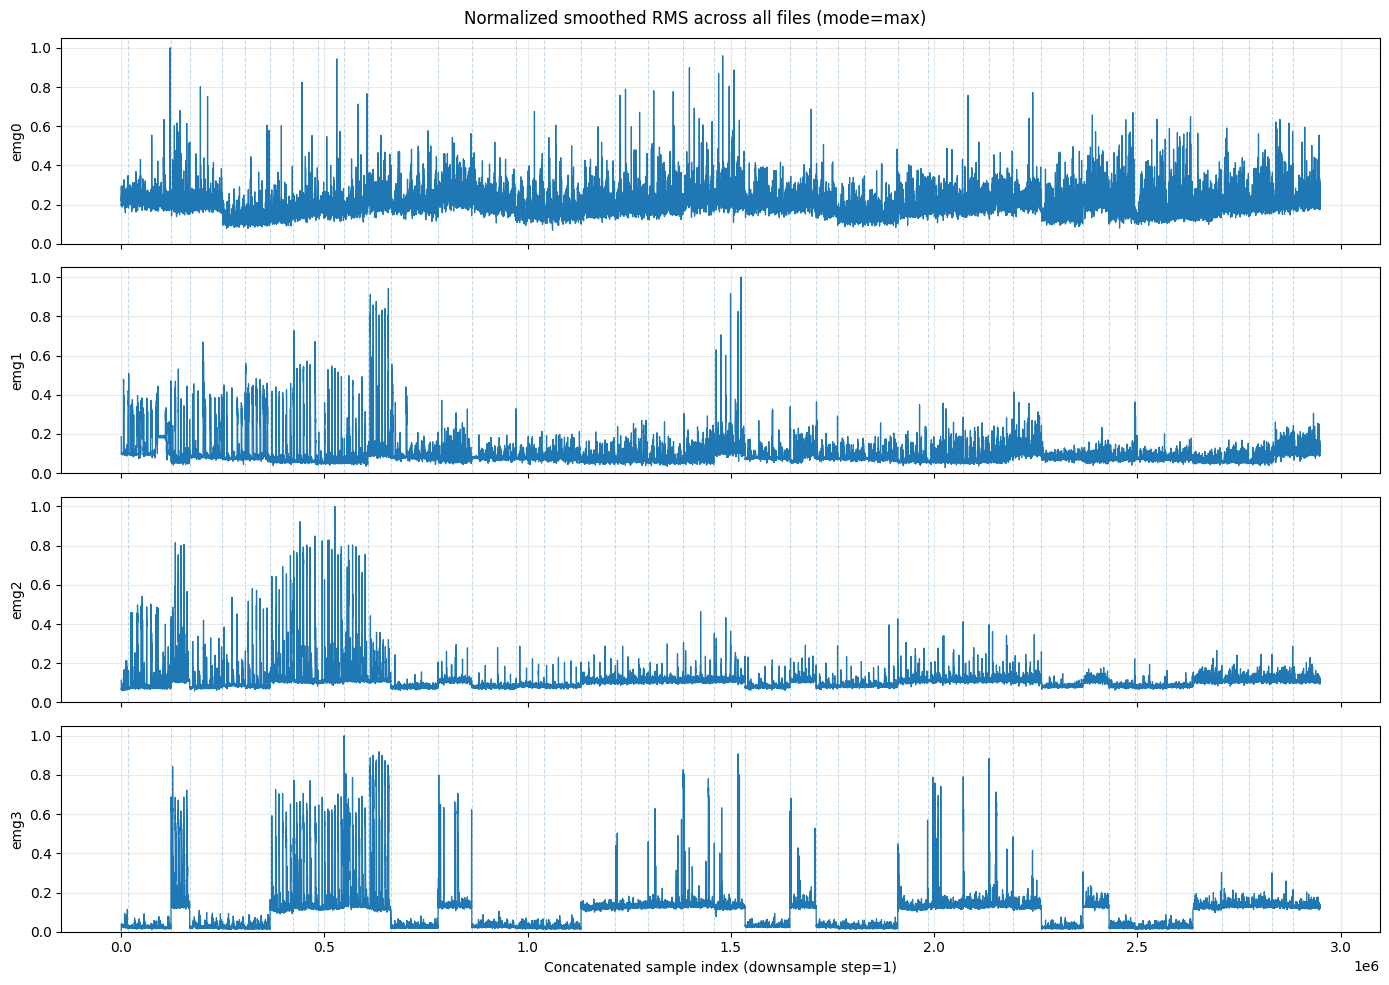

In [270]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# NORMALIZATION across ALL files (per channel)
# =========================
# Choose one:
NORM_MODE = "max"   # "max" or "p99_5"
EPS = 1e-12

if NORM_MODE == "max":
    denom = np.nanmax(env_smooth, axis=0)  # shape (4,)
elif NORM_MODE == "p99_5":
    denom = np.nanpercentile(env_smooth, 99.5, axis=0)
else:
    raise ValueError("NORM_MODE must be 'max' or 'p99_5'")

denom = np.maximum(denom, EPS)

env_norm = env_smooth / denom   # shape (N,4)

print("Normalization denominators per channel:")
for i, name in enumerate(TARGET_EMG_COLS):
    print(f"  {name}: {denom[i]:.6g}")

# ===== Downsample for plotting (same as before) =====
if step > 1:
    env_norm_plot = env_norm[::step, :]
else:
    env_norm_plot = env_norm

# =========================
# Plot normalized envelope
# =========================
fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, ch_name in enumerate(TARGET_EMG_COLS):
    axs[i].plot(x, env_norm_plot[:, i], lw=0.9)
    axs[i].set_ylabel(ch_name)
    axs[i].set_ylim(0, 1.05)  # normalized
    for b in boundaries_plot[1:-1]:
        axs[i].axvline(b, linestyle="--", linewidth=0.8, alpha=0.25)
    axs[i].grid(alpha=0.25)

axs[-1].set_xlabel(f"Concatenated sample index (downsample step={step})")
fig.suptitle(f"Normalized smoothed RMS across all files (mode={NORM_MODE})", y=0.98)
plt.tight_layout()
plt.show()


In [273]:
from pathlib import Path
import numpy as np
import pandas as pd

# =========================
# CONFIG
# =========================
OUT_CSV = Path("/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/synced/emg_env_norm_all_files1.csv")   # <- output file
META_COLS = ["timestamp", "trial_id", "label", "mark", "host_rel_s", "device_s"]

# normalization mode: robust is recommended
NORM_MODE = "max"   # "max" or "p99_5"
EPS = 1e-12

# RMS settings (same as you used)
fs = 1000.0
rms_win_ms = 50
smooth_win_ms = 200

rms_win = max(1, int(round(rms_win_ms * 1e-3 * fs)))
smooth_win = max(1, int(round(smooth_win_ms * 1e-3 * fs)))

print(f"RMS: fs={fs}Hz -> rms_win={rms_win} samples, smooth_win={smooth_win} samples")

# =========================
# Helpers (RMS)
# =========================
def moving_mean_same(x: np.ndarray, win: int) -> np.ndarray:
    win = int(win)
    if win <= 1:
        return x.astype(float)
    pad_left = win // 2
    pad_right = win - 1 - pad_left
    xpad = np.pad(x.astype(float), (pad_left, pad_right), mode="edge")
    c = np.cumsum(np.insert(xpad, 0, 0.0))
    return (c[win:] - c[:-win]) / win

def rms_envelope_1d(x: np.ndarray, win: int) -> np.ndarray:
    return np.sqrt(moving_mean_same(x**2, win))

# =========================
# Load -> despike -> per-file RMS smooth
# =========================
frames = []          # per-file meta dataframe (aligned to samples)
env_smooth_list = [] # per-file env_smooth arrays (N,4)
file_names = []

for fp in files:
    try:
        df_raw = _read_table(fp)
        df = _normalize_cols(df_raw)

        # If modality exists, keep EMG only
        if "modality" in df.columns:
            df = df[df["modality"].astype(str).str.lower().eq("emg")].copy()

        # find EMG cols
        mapping = _find_emg_cols(df)
        missing = [c for c in TARGET_EMG_COLS if c not in mapping]
        if missing:
            raise ValueError(f"missing {missing}")

        # ensure meta cols exist (create if missing)
        for c in META_COLS:
            if c not in df.columns:
                df[c] = np.nan

        # parse timestamp
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

        # numeric for meta times
        for c in ["host_rel_s", "device_s"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")

        # numeric EMG + drop NaNs
        for t in TARGET_EMG_COLS:
            df[mapping[t]] = pd.to_numeric(df[mapping[t]], errors="coerce")
        df_use = df.dropna(subset=["timestamp", *[mapping[t] for t in TARGET_EMG_COLS]]).copy()

        # build X (raw)
        X = np.column_stack([df_use[mapping[t]].to_numpy(dtype=float) for t in TARGET_EMG_COLS])

        # --- IMPORTANT: disable ADC rail mask if your data is normalized (~0..1) ---
        # If values look small, don't use 0/4095 rail logic.
        vmax = np.nanmax(X)
        if vmax <= 5.0:
            adc_min, adc_max, rail_margin = -1e9, 1e9, 0.0
        else:
            adc_min, adc_max, rail_margin = 0, 4095, 5

        # despike (Hampel + optional rail mask)
        X, _ = despike_emg_matrix(
            X,
            adc_min=adc_min, adc_max=adc_max,
            rail_margin=rail_margin,
            hampel_win=101,
            hampel_nsig=6.0,
            interp=True
        )

        # per-file RMS + smooth (NO boundary bleed)
        env_rms = np.zeros_like(X, dtype=float)
        env_smooth = np.zeros_like(X, dtype=float)
        for ch in range(4):
            env_rms[:, ch] = rms_envelope_1d(X[:, ch], rms_win)
            env_smooth[:, ch] = moving_mean_same(env_rms[:, ch], smooth_win)

        # store meta frame aligned to samples
        meta = df_use[META_COLS].copy()
        meta["source_file"] = fp.name

        frames.append(meta.reset_index(drop=True))
        env_smooth_list.append(env_smooth)
        file_names.append(fp.name)

    except Exception as e:
        print(f"[Skip] {fp.name}: {e}")

if len(frames) == 0:
    raise RuntimeError("No usable files processed; nothing to save.")

# =========================
# Global normalization across ALL files (per channel)
# =========================
env_smooth_all = np.vstack(env_smooth_list)  # (totalN,4)

if NORM_MODE == "max":
    denom = np.nanmax(env_smooth_all, axis=0)
elif NORM_MODE == "p99_5":
    denom = np.nanpercentile(env_smooth_all, 99.5, axis=0)
else:
    raise ValueError("NORM_MODE must be 'max' or 'p99_5'")

denom = np.maximum(denom, EPS)

print("Normalization denominators:")
for i, nm in enumerate(TARGET_EMG_COLS):
    print(f"  {nm}: {denom[i]:.6g}")

# =========================
# Build output dataframe and save
# =========================
out_parts = []
for meta, env_smooth in zip(frames, env_smooth_list):
    env_norm = env_smooth / denom  # (N,4)

    df_out = meta.copy()
    # keep mark blank instead of NaN (matches your original CSV style)
    if "mark" in df_out.columns:
        df_out["mark"] = df_out["mark"].fillna("")

    # write normalized values into emg0..emg3 (normalized smoothed RMS)
    for i, nm in enumerate(TARGET_EMG_COLS):
        df_out[nm] = env_norm[:, i]

    # order columns like you asked
    df_out = df_out[["timestamp","trial_id","label","mark","host_rel_s","device_s","source_file",
                     "emg0","emg1","emg2","emg3"]]
    out_parts.append(df_out)

df_final = pd.concat(out_parts, ignore_index=True)

df_final.to_csv(OUT_CSV, index=False, date_format="%Y-%m-%d %H:%M:%S.%f")
print(f"Saved -> {OUT_CSV}   rows={len(df_final)}")
print(df_final.head(3))


RMS: fs=1000.0Hz -> rms_win=50 samples, smooth_win=200 samples
Normalization denominators:
  emg0: 144.953
  emg1: 1627.71
  emg2: 1053.93
  emg3: 2137.99
Saved -> /Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/synced/emg_env_norm_all_files1.csv   rows=2949419
                   timestamp  trial_id label mark  host_rel_s     device_s  \
0 2026-04-09 17:55:33.629590       0.0  rest         0.697080  1313.102875   
1 2026-04-09 17:55:33.629738       0.0  rest         0.697227  1313.103875   
2 2026-04-09 17:55:33.629757       0.0  rest         0.697247  1313.104875   

  source_file      emg0      emg1      emg2      emg3  
0     1-0.csv  0.202788  0.185941  0.113108  0.003949  
1     1-0.csv  0.202862  0.185790  0.113055  0.004051  
2     1-0.csv  0.202927  0.185630  0.112998  0.004156  
